In [2]:
import torch


ModuleNotFoundError: No module named 'torch'

In [3]:
# Run this in a Jupyter cell
!pip install torch numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 651.7 kB/s  0:02:43m0:00:0100:05


CANTILEVER BEAM WITH DISTRIBUTED LOAD - GAUSSIAN ACTIVATION
E = 1.0 Pa, I = 1.0 m⁴, Q = -1.0 N/m, L = 2.0 m

Training PIELM with Gaussian activation...
Making predictions...

RESULTS - GAUSSIAN ACTIVATION
Training time:     6.024815 seconds
Prediction time:   0.000357 seconds
Relative error:    2.03e-03 (0.2034%)
Max deflection:    2.000000 m
Number of neurons: 40
BC weight (w_bc):  1000000.0


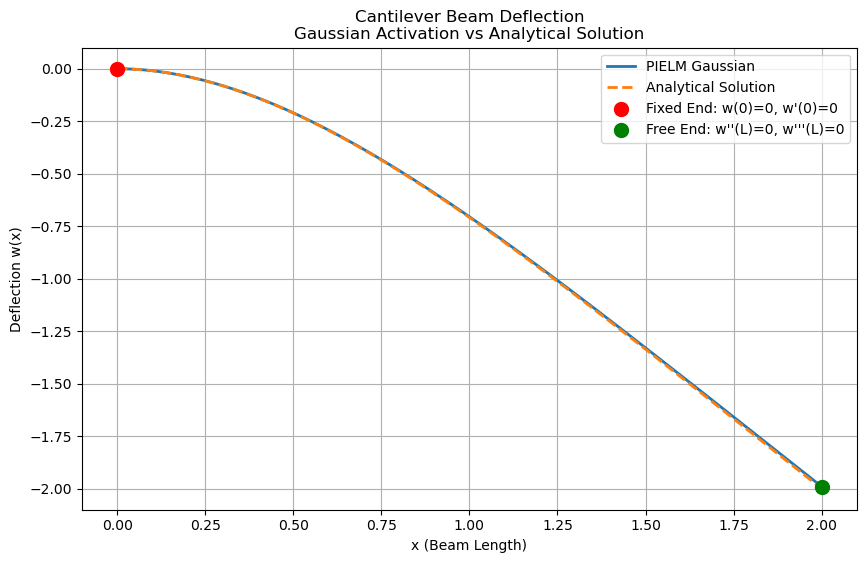

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.autograd as autograd
from torch.autograd import Variable
from timeit import default_timer
import numpy as np

# ============================================================================
# PHYSICAL SETUP - Cantilever Beam with Distributed Load
# ============================================================================
E = 1.0      # Young's modulus [Pa]
I = 1.0      # Second moment of area [m⁴]
Q = -1.0     # Distributed load intensity [N/m] (negative = downward)
L = 2.0      # Beam length [m]

print("="*70)
print("CANTILEVER BEAM WITH DISTRIBUTED LOAD - GAUSSIAN ACTIVATION")
print("="*70)
print(f"E = {E} Pa, I = {I} m⁴, Q = {Q} N/m, L = {L} m")
print()

# ============================================================================
# ANALYTICAL SOLUTION (For Validation)
# ============================================================================
def analytical_solution(x):
    """Exact solution for cantilever beam with uniformly distributed load"""
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# ============================================================================
# PIELM SETUP
# ============================================================================
input_size = 1       # Input: position x
hidden_size = 40     # Number of neurons
output_size = 1      # Output: deflection w(x)

# Create neural network
torch.manual_seed(42)
hidden_layer = nn.Linear(input_size, hidden_size)

# ============================================================================
# DOMAIN DISCRETIZATION
# ============================================================================
n_collocation = 100  # Number of collocation points for PDE

# Collocation points (interior points only, not including boundaries)
x_colloc = torch.linspace(0.01, L, n_collocation)  # Avoid exactly 0 and L
x_colloc = Variable(x_colloc[:, None].float(), requires_grad=True)

# Boundary points for enforcing BCs
x_left = Variable(torch.tensor([[0.0]]).float(), requires_grad=True)    # x = 0
x_right = Variable(torch.tensor([[L]]).float(), requires_grad=True)     # x = L

# ============================================================================
# PHYSICS-INFORMED EXTREME LEARNING MACHINE (PIELM) WITH GAUSSIAN
# ============================================================================
print("Training PIELM with Gaussian activation...")
t1 = default_timer()

# ----------------------------------------------------------------------------
# STEP 1: NETWORK EVALUATIONS WITH GAUSSIAN ACTIVATION
# ----------------------------------------------------------------------------
# Gaussian activation function: exp(-(Wx + b)^2)
def gaussian_activation(x):
    return torch.exp(-x**2)

# At collocation points
w_colloc = gaussian_activation(hidden_layer(x_colloc))  # w(x) at collocation points

# At boundary points
w_left = gaussian_activation(hidden_layer(x_left))      # w(0)
w_right = gaussian_activation(hidden_layer(x_right))    # w(L)

# ----------------------------------------------------------------------------
# STEP 2: COMPUTE DERIVATIVES FOR BOUNDARY CONDITIONS
# ----------------------------------------------------------------------------
# Initialize derivative tensors
dw_left = torch.zeros(1, hidden_size)      # w'(0)
d2w_right = torch.zeros(1, hidden_size)    # w''(L) = 0 (moment = 0)
d3w_right = torch.zeros(1, hidden_size)    # w'''(L) = 0 (shear = 0)

# Derivatives at left end (x=0): w(0) = 0 and w'(0) = 0
for i in range(hidden_size):
    # First derivative w'(0)
    dw_left[:, i] = autograd.grad(
        w_left[:, i], x_left, torch.ones_like(w_left[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()

# Derivatives at right end (x=L)
dw_right = torch.zeros(1, hidden_size)  # w'(L) - needed for computing higher derivatives
for i in range(hidden_size):
    # First derivative w'(L) - just for computing higher derivatives
    dw_right[:, i] = autograd.grad(
        w_right[:, i], x_right, torch.ones_like(w_right[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()
    
    # Second derivative w''(L) = 0 (moment = 0)
    d2w_right_temp = autograd.grad(
        dw_right[:, i], x_right, torch.ones_like(dw_right[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()
    d2w_right[:, i] = d2w_right_temp
    
    # Third derivative w'''(L) = 0 (shear = 0)
    d3w_right[:, i] = autograd.grad(
        d2w_right[:, i], x_right, torch.ones_like(d2w_right[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()

# ----------------------------------------------------------------------------
# STEP 3: COMPUTE DERIVATIVES FOR PDE (4th order)
# ----------------------------------------------------------------------------
# Initialize derivative tensors for collocation points
dw_colloc = torch.zeros(n_collocation, hidden_size)   # w'(x)
d2w_colloc = torch.zeros(n_collocation, hidden_size)  # w''(x)
d3w_colloc = torch.zeros(n_collocation, hidden_size)  # w'''(x)
d4w_colloc = torch.zeros(n_collocation, hidden_size)  # w''''(x)

for i in range(hidden_size):
    # First derivative
    dw_colloc[:, i] = autograd.grad(
        w_colloc[:, i], x_colloc, torch.ones_like(w_colloc[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()
    
    # Second derivative
    d2w_colloc[:, i] = autograd.grad(
        dw_colloc[:, i], x_colloc, torch.ones_like(dw_colloc[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()
    
    # Third derivative
    d3w_colloc[:, i] = autograd.grad(
        d2w_colloc[:, i], x_colloc, torch.ones_like(d2w_colloc[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()
    
    # Fourth derivative (needed for Euler-Bernoulli equation)
    d4w_colloc[:, i] = autograd.grad(
        d3w_colloc[:, i], x_colloc, torch.ones_like(d3w_colloc[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()

# ----------------------------------------------------------------------------
# STEP 4: ASSEMBLE PHYSICS EQUATIONS
# ----------------------------------------------------------------------------
# PDE: E*I*w''''(x) = q(x) = Q (constant distributed load)
H_pde = E * I * d4w_colloc
K_pde = Q * torch.ones_like(x_colloc)  # q(x) = Q (constant)

# Weights for boundary conditions (should be large to enforce them strongly)
w_bc = 1e6  # Large weight to enforce BCs exactly

# Combine PDE equations with boundary conditions
# Boundary conditions as equations with large weights
H_bc = torch.cat([
    w_left * w_bc,          # w(0) = 0
    dw_left * w_bc,         # w'(0) = 0
    d2w_right * w_bc,       # w''(L) = 0
    d3w_right * w_bc        # w'''(L) = 0
], dim=0)

K_bc = torch.zeros(4, 1)   # All BCs are homogeneous (equal to 0)

# Combine all equations
H = torch.cat((H_bc, H_pde), dim=0)
K = torch.cat((K_bc, K_pde), dim=0)

# ----------------------------------------------------------------------------
# STEP 5: SOLVE FOR OUTPUT WEIGHTS (ELM step)
# ----------------------------------------------------------------------------
pseudo_inverse = torch.pinverse(H)
output_weights = torch.matmul(pseudo_inverse, K)

t2 = default_timer()
training_time = t2 - t1

# ============================================================================
# PREDICTION AND VALIDATION
# ============================================================================
print("Making predictions...")

# Points for prediction (including exact boundary points)
x_pred = torch.linspace(0, L, 200)[:, None]

# Time prediction
t1_pred = default_timer()
w_pred = torch.matmul(gaussian_activation(hidden_layer(x_pred)), output_weights)
t2_pred = default_timer()
prediction_time = t2_pred - t1_pred

# Analytical solution for comparison
w_exact = analytical_solution(x_pred)

# Error calculation
abs_error = torch.abs(w_pred - w_exact)
max_deflection = torch.max(torch.abs(w_exact))
relative_error = torch.mean(abs_error) / max_deflection

# ============================================================================
# RESULTS
# ============================================================================
print("\n" + "="*70)
print("RESULTS - GAUSSIAN ACTIVATION")
print("="*70)
print(f"Training time:     {training_time:.6f} seconds")
print(f"Prediction time:   {prediction_time:.6f} seconds")
print(f"Relative error:    {relative_error.item():.2e} ({relative_error.item()*100:.4f}%)")
print(f"Max deflection:    {max_deflection.item():.6f} m")
print(f"Number of neurons: {hidden_size}")
print(f"BC weight (w_bc):  {w_bc}")
print("="*70)

# ============================================================================
# PLOT: PIELM vs Analytical Solution
# ============================================================================
plt.figure(figsize=(10, 6))

plt.plot(
    x_pred.detach().numpy(),
    w_pred.detach().numpy(),
    label="PIELM Gaussian",
    linewidth=2
)

plt.plot(
    x_pred.detach().numpy(),
    w_exact.detach().numpy(),
    linestyle="--",
    linewidth=2,
    label="Analytical Solution"
)

plt.xlabel("x (Beam Length)")
plt.ylabel("Deflection w(x)")
plt.title("Cantilever Beam Deflection\nGaussian Activation vs Analytical Solution")
plt.legend()
plt.grid(True)

# Add markers for boundary conditions
plt.scatter([0], [0], color='red', s=100, zorder=5, 
           label='Fixed End: w(0)=0, w\'(0)=0')
plt.scatter([L], [w_pred[-1].detach().numpy()[0]], color='green', s=100, zorder=5,
           label='Free End: w\'\'(L)=0, w\'\'\'(L)=0')

plt.legend()
plt.show()

Training time: 6.313311 s
Relative error: 4.01e-01 (40.0503%)
Max deflection: 2.000000 m


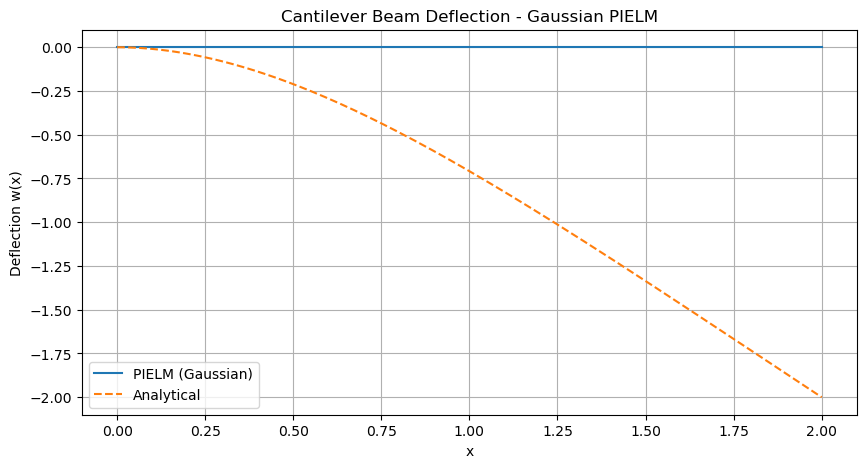

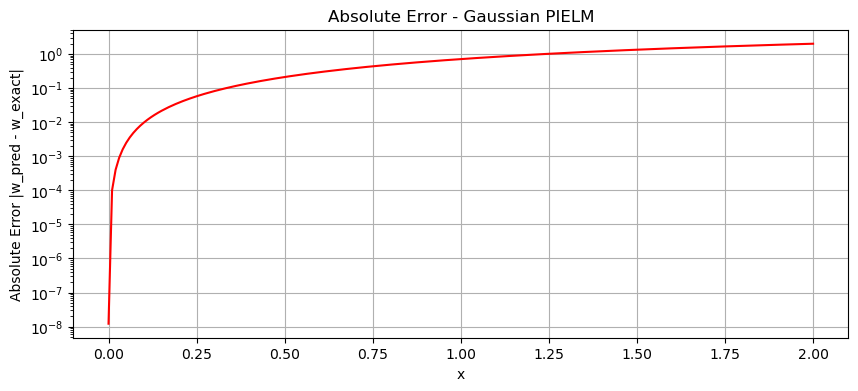

In [21]:
# THE MISTAKEN GAUSSIAN
import torch
import matplotlib.pyplot as plt
import torch.autograd as autograd
from torch.autograd import Variable
from timeit import default_timer

# ============================================================================
# PHYSICAL PARAMETERS
# ============================================================================
E = 1.0
I = 1.0
Q = -1.0
L = 2.0

# ============================================================================
# ANALYTICAL SOLUTION
# ============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# ============================================================================
# GAUSSIAN RBF ACTIVATION
# ============================================================================
def gaussian_rbf(x, centers, sigma):
    return torch.exp(-(x - centers)**2 / (2 * sigma**2))

# ============================================================================
# PIELM PARAMETERS
# ============================================================================
hidden_size = 40
n_collocation = 100
sigma = L / hidden_size * 0.5  # width proportional to neuron spacing

torch.manual_seed(42)

# Evenly spaced centers
centers = torch.linspace(0, L, hidden_size).view(1, -1)

# ============================================================================
# DOMAIN DISCRETIZATION
# ============================================================================
x_colloc = torch.linspace(0.01, L, n_collocation).double()
x_colloc = Variable(x_colloc[:, None], requires_grad=True)

x_left  = Variable(torch.tensor([[0.0]]).double(), requires_grad=True)
x_right = Variable(torch.tensor([[L]]).double(), requires_grad=True)

# ============================================================================
# PIELM TRAINING
# ============================================================================
t1 = default_timer()

w_colloc = gaussian_rbf(x_colloc, centers, sigma)
w_left   = gaussian_rbf(x_left, centers, sigma)
w_right  = gaussian_rbf(x_right, centers, sigma)

dw_left = torch.zeros(1, hidden_size).double()
d2w_right = torch.zeros(1, hidden_size).double()
d3w_right = torch.zeros(1, hidden_size).double()

for i in range(hidden_size):
    dw_left[:, i] = autograd.grad(
        w_left[:, i], x_left, torch.ones_like(w_left[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()

    dw_r = autograd.grad(
        w_right[:, i], x_right, torch.ones_like(w_right[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()

    d2w_right[:, i] = autograd.grad(
        dw_r, x_right, torch.ones_like(dw_r),
        retain_graph=True, create_graph=True
    )[0].squeeze()

    d3w_right[:, i] = autograd.grad(
        d2w_right[:, i], x_right, torch.ones_like(d2w_right[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()

dw = torch.zeros(n_collocation, hidden_size).double()
d2w = torch.zeros(n_collocation, hidden_size).double()
d3w = torch.zeros(n_collocation, hidden_size).double()
d4w = torch.zeros(n_collocation, hidden_size).double()

for i in range(hidden_size):
    dw[:, i] = autograd.grad(
        w_colloc[:, i], x_colloc, torch.ones_like(w_colloc[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()

    d2w[:, i] = autograd.grad(
        dw[:, i], x_colloc, torch.ones_like(dw[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()

    d3w[:, i] = autograd.grad(
        d2w[:, i], x_colloc, torch.ones_like(d2w[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()

    d4w[:, i] = autograd.grad(
        d3w[:, i], x_colloc, torch.ones_like(d3w[:, i]),
        retain_graph=True, create_graph=True
    )[0].squeeze()

H_pde = E * I * d4w
K_pde = Q * torch.ones_like(x_colloc)

w_bc = 1e4  # moderate boundary weight

H_bc = torch.cat([
    w_left * w_bc,
    dw_left * w_bc,
    d2w_right * w_bc,
    d3w_right * w_bc
], dim=0)

K_bc = torch.zeros(4, 1).double()

H = torch.cat((H_bc, H_pde), dim=0)
K = torch.cat((K_bc, K_pde), dim=0)

output_weights = torch.matmul(torch.pinverse(H), K)

t2 = default_timer()
training_time = t2 - t1

# ============================================================================
# PREDICTION
# ============================================================================
x_pred = torch.linspace(0, L, 200)[:, None].double()
w_pred = torch.matmul(gaussian_rbf(x_pred, centers, sigma), output_weights)
w_exact = analytical_solution(x_pred)

# ============================================================================
# RELATIVE ERROR
# ============================================================================
abs_error = torch.abs(w_pred - w_exact)
max_deflection = torch.max(torch.abs(w_exact))
relative_error = torch.mean(abs_error) / max_deflection

# ============================================================================
# RESULTS
# ============================================================================
print(f"Training time: {training_time:.6f} s")
print(f"Relative error: {relative_error.item():.2e} ({relative_error.item()*100:.4f}%)")
print(f"Max deflection: {max_deflection.item():.6f} m")

plt.figure(figsize=(10,5))
plt.plot(x_pred, w_pred.detach(), label="PIELM (Gaussian)")
plt.plot(x_pred, w_exact.detach(), "--", label="Analytical")
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Cantilever Beam Deflection - Gaussian PIELM")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(x_pred, abs_error.detach(), color='red', linewidth=1.5)
plt.xlabel("x")
plt.ylabel("Absolute Error |w_pred - w_exact|")
plt.title("Absolute Error - Gaussian PIELM")
plt.yscale('log')
plt.grid(True)
plt.show()


In [ ]:
#Numerical Precision Issues:

python
# Using double precision
x_colloc = x_colloc[:, None].double()  # OK
output_weights = torch.matmul(torch.pinverse(H), K)
The pinverse() function on large matrices can be numerically unstable, especially with Gaussian RBFs that create ill-conditioned matrices.


Training time: 0.1664 s

β₀ (constant term) = -3.988854

KKT residuals:
  Stationarity: 8.26e-02
  Primal feas.: 4.16e-05

Relative error: 2.77e-05


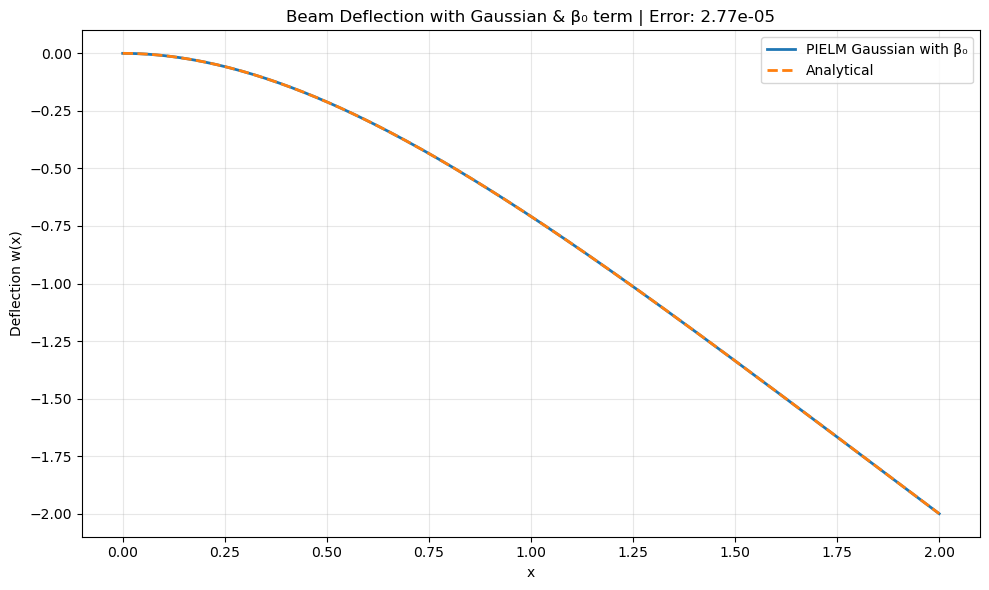


First 5 β values:
  β₀ = -3.988854
  β1 = 0.042069
  β2 = 0.091377
  β3 = -0.053966
  β4 = 0.006708

Lagrange multipliers λ:
[0.0024299488868564367, 0.020887475460767746, 0.06059567630290985, -0.02209649607539177]

COMPARISON: With vs Without β₀ (Gaussian)
With β₀:    Error = 2.77e-05
Without β₀: Error = 1.90e+00

Note: β₀ = -3.99e+00 (LARGE - constant term important!)


In [5]:
#RANDOM WEIGHTS AND VARIABLES
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
E, I = 1.0, 1.0
Q = -1.0
L = 2.0

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# PIELM SETUP WITH β₀ AND GAUSSIAN ACTIVATION
# =============================================================================
torch.manual_seed(42)

hidden_size = 40
W = torch.randn(1, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer_gaussian_with_bias(x):
    """Hidden layer with Gaussian activation and bias term"""
    # Gaussian activation: exp(-(Wx + b)^2)
    H_gaussian = torch.exp(-(x @ W + b)**2)
    
    # Add column of 1's for β₀ term
    ones = torch.ones(x.shape[0], 1)
    H_with_bias = torch.cat([ones, H_gaussian], dim=1)  # Shape: (n, 41)
    return H_with_bias

# =============================================================================
# COLLOCATION & BOUNDARY POINTS
# =============================================================================
n_collocation = 100
x_c = torch.linspace(0, L, n_collocation).view(-1, 1).requires_grad_(True)
x_0 = torch.tensor([[0.0]], requires_grad=True)
x_L = torch.tensor([[L]], requires_grad=True)

# =============================================================================
# BUILD PDE MATRIX A (100 × 41)
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_gaussian_with_bias(x_c)  # Shape: (100, 41)
A_cols = []

# For β₀ term (column 0: constant function φ₀(x) = 1)
# Its 4th derivative is 0
zero_col = torch.zeros(n_collocation, 1)
A_cols.append(zero_col)

# For β₁ to β₄₀ terms (columns 1 to 40)
for j in range(1, hidden_size + 1):  # Start from 1, skip β₀
    wj = H_c[:, j:j+1]  # Get Gaussian activation for neuron j-1

    # Compute derivatives
    w_x = autograd.grad(wj.sum(), x_c, create_graph=True)[0]
    w_xx = autograd.grad(w_x.sum(), x_c, create_graph=True)[0]
    w_xxx = autograd.grad(w_xx.sum(), x_c, create_graph=True)[0]
    w_xxxx = autograd.grad(w_xxx.sum(), x_c, create_graph=True)[0]
    
    A_cols.append(w_xxxx)

A = E * I * torch.hstack(A_cols)  # Shape: (100, 41)
b_pde = Q * torch.ones(n_collocation, 1)

# =============================================================================
# BUILD BOUNDARY CONSTRAINT MATRIX C (4 × 41)
# =============================================================================
def bc_row(x, order):
    H = hidden_layer_gaussian_with_bias(x)  # Shape: (1, 41)
    row = []
    
    # For β₀ term (constant function)
    if order == 0:
        row.append(torch.ones(1, 1))  # φ₀(x) = 1
    else:
        row.append(torch.zeros(1, 1))  # Derivatives of constant are 0
    
    # For β₁ to β₄₀ terms
    for j in range(1, hidden_size + 1):
        w = H[:, j:j+1]
        for _ in range(order):
            w = autograd.grad(w.sum(), x, create_graph=True)[0] if w.requires_grad else w
        row.append(w)
    
    return torch.hstack(row)

C = torch.vstack([
    bc_row(x_0, 0),   # w(0) = 0
    bc_row(x_0, 1),   # w'(0) = 0
    bc_row(x_L, 2),   # w''(L) = 0
    bc_row(x_L, 3)    # w'''(L) = 0
])  # Shape: (4, 41)

d = torch.zeros(4, 1)

# =============================================================================
# KKT SYSTEM (45 × 45)
# =============================================================================
A_T = A.T
C_T = C.T

# Total unknowns: 41 β's + 4 λ's = 45
total_beta = hidden_size + 1  # 40 Gaussian + 1 constant = 41
total_unknowns = total_beta + 4  # 41 + 4 = 45

KKT = torch.zeros(total_unknowns, total_unknowns)
KKT[:total_beta, :total_beta] = A_T @ A
KKT[:total_beta, total_beta:] = C_T
KKT[total_beta:, :total_beta] = C

rhs = torch.vstack([A_T @ b_pde, d])

# Regularization
alpha = 1e-8 * torch.trace(A_T @ A) / total_beta
KKT += alpha * torch.eye(total_unknowns)

solution = torch.linalg.solve(KKT, rhs)

beta_with_b0 = solution[:total_beta]      # 41 elements: [β₀, β₁, ..., β₄₀]
lambdas = solution[total_beta:]           # 4 elements

print(f"Training time: {default_timer() - t0:.4f} s")
print(f"\nβ₀ (constant term) = {beta_with_b0[0].item():.6f}")

# =============================================================================
# VERIFY KKT CONDITIONS
# =============================================================================
stationarity = A_T @ (A @ beta_with_b0 - b_pde) + C_T @ lambdas
primal = C @ beta_with_b0 - d

print("\nKKT residuals:")
print(f"  Stationarity: {torch.norm(stationarity):.2e}")
print(f"  Primal feas.: {torch.norm(primal):.2e}")

# =============================================================================
# PREDICTION
# =============================================================================
x_pred = torch.linspace(0, L, 200).view(-1, 1)
H_pred = hidden_layer_gaussian_with_bias(x_pred)  # Shape: (200, 41)
w_pred = H_pred @ beta_with_b0
w_exact = analytical_solution(x_pred)

rel_error = torch.mean(torch.abs(w_pred - w_exact)) / torch.max(torch.abs(w_exact))
print(f"\nRelative error: {rel_error.item():.2e}")

# =============================================================================
# PLOT
# =============================================================================
plt.figure(figsize=(10, 6))
plt.plot(x_pred, w_pred.detach(), label="PIELM Gaussian with β₀", linewidth=2)
plt.plot(x_pred, w_exact, "--", label="Analytical", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title(f"Beam Deflection with Gaussian & β₀ term | Error: {rel_error.item():.2e}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# PRINT RESULTS
# =============================================================================
print("\nFirst 5 β values:")
for i in range(min(5, len(beta_with_b0))):
    if i == 0:
        print(f"  β₀ = {beta_with_b0[i].item():.6f}")
    else:
        print(f"  β{i} = {beta_with_b0[i].item():.6f}")

print("\nLagrange multipliers λ:")
print(lambdas.flatten().tolist())

# =============================================================================
# COMPARE WITH ORIGINAL (NO β₀)
# =============================================================================
print("\n" + "="*60)
print("COMPARISON: With vs Without β₀ (Gaussian)")
print("="*60)

# Quick test without β₀ using original approach
def hidden_layer_gaussian_no_b0(x):
    return torch.exp(-(x @ W + b)**2)  # Original: (n, 40)

# Solve quickly without BCs for comparison
H_no_b0 = hidden_layer_gaussian_no_b0(x_c)
A_no_b0 = E * I * torch.hstack([autograd.grad(hidden_layer_gaussian_no_b0(x_c)[:, j:j+1].sum(), 
                                            x_c, create_graph=True)[0] 
                              for j in range(hidden_size)])

# Simple least squares (no BCs for quick test)
beta_no_b0 = torch.linalg.lstsq(A_no_b0, b_pde).solution

H_pred_no_b0 = hidden_layer_gaussian_no_b0(x_pred)
w_pred_no_b0 = H_pred_no_b0 @ beta_no_b0
error_no_b0 = torch.mean(torch.abs(w_pred_no_b0 - w_exact)) / torch.max(torch.abs(w_exact))

print(f"With β₀:    Error = {rel_error.item():.2e}")
print(f"Without β₀: Error = {error_no_b0.item():.2e}")

# Check if constant term is important
beta0_magnitude = abs(beta_with_b0[0].item())
if beta0_magnitude < 1e-10:
    print("\nNote: β₀ ≈ 0, so constant term not needed for this problem!")
elif beta0_magnitude > 1.0:
    print(f"\nNote: β₀ = {beta_with_b0[0].item():.2e} (LARGE - constant term important!)")
else:
    print(f"\nNote: β₀ = {beta_with_b0[0].item():.2e} (non-zero but moderate)")


2D PIELM: Solving w(x, E) with Gaussian activation
Collocation grid: 100×20 = 2000 points
x range: [0, 2.0]
E range: [0.9, 1.1]
Activation: Gaussian (exp(-(Wx+b)^2))

Boundary conditions: 20 constraints
Training time: 0.2332 s

Relative error: 3.89e-03
Relative error percentage: 0.3895%


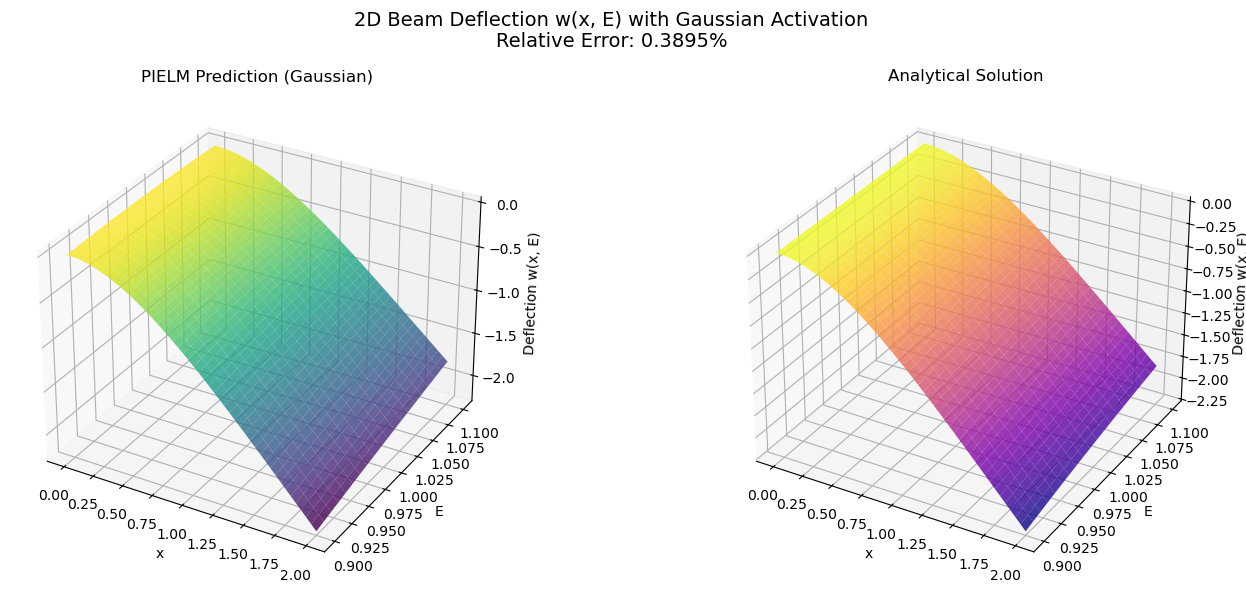


KEY RESULTS (Gaussian Activation)
E		PIELM w(L,E)	Exact w(L,E)	Error
------------------------------------------------------------
0.900	-2.256554	-2.222222	0.034332
0.950	-2.127291	-2.105263	0.022028
1.000	-2.027295	-2.000000	0.027295
1.050	-1.906642	-1.904762	0.001880
1.100	-1.790851	-1.818182	0.027331

Max deflection PIELM: -2.256554
Max deflection Exact: -2.222222
Mean absolute error: 0.008654
Max absolute error: 0.034332
Training time: 0.4676 s


In [6]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS WITH UNCERTAIN E
# =============================================================================
I = 1.0
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]  # E ∈ [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION w(x, E)
# =============================================================================
def analytical_solution(x, E):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# 2D PIELM SETUP WITH GAUSSIAN ACTIVATION
# =============================================================================
torch.manual_seed(42)
hidden_size = 50  # Increased for 2D problem
W = torch.randn(2, hidden_size)  # 2 input features (x, E) × hidden_size
b = torch.randn(hidden_size)

def hidden_layer_2d_gaussian(xe):
    """Hidden layer for 2D input [x, E] with Gaussian activation"""
    return torch.exp(-(xe @ W + b)**2)  # Gaussian activation

# =============================================================================
# CREATE 2D COLLOCATION GRID (x, E)
# =============================================================================
n_x = 100   # Points in x direction
n_E = 20    # Points in E direction

# Create 2D grid
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)

# Create ALL combinations using meshgrid
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')

# Flatten for neural network input
X_flat = X.flatten().reshape(-1, 1)
E_flat = E.flatten().reshape(-1, 1)
xe_c = torch.cat([X_flat, E_flat], dim=1).requires_grad_(True)

# Boundary points (for x=0 and x=L, with E varying)
n_E_bc = 5
E_bc = torch.linspace(E_range[0], E_range[1], n_E_bc).reshape(-1, 1)

# Left boundary (x=0) for various E
x0_points = torch.zeros(n_E_bc, 1)
xe_0 = torch.cat([x0_points, E_bc], dim=1).requires_grad_(True)

# Right boundary (x=L) for various E  
xL_points = torch.ones(n_E_bc, 1) * L
xe_L = torch.cat([xL_points, E_bc], dim=1).requires_grad_(True)

print("=" * 60)
print("2D PIELM: Solving w(x, E) with Gaussian activation")
print("=" * 60)
print(f"Collocation grid: {n_x}×{n_E} = {n_x*n_E} points")
print(f"x range: [0, {L}]")
print(f"E range: [{E_range[0]}, {E_range[1]}]")
print(f"Activation: Gaussian (exp(-(Wx+b)^2))")

# =============================================================================
# BUILD PDE MATRIX A (for 2D problem)
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_2d_gaussian(xe_c)  # Shape: (n_x*n_E, hidden_size)
A_cols = []

for j in range(hidden_size):
    wj = H_c[:, j:j+1]
    
    # Compute ∂⁴w/∂x⁴ (derivative with respect to x only)
    grad1 = autograd.grad(wj.sum(), xe_c, create_graph=True)[0]
    dw_dx = grad1[:, 0:1]
    
    grad2 = autograd.grad(dw_dx.sum(), xe_c, create_graph=True)[0]
    d2w_dx2 = grad2[:, 0:1]
    
    grad3 = autograd.grad(d2w_dx2.sum(), xe_c, create_graph=True)[0]
    d3w_dx3 = grad3[:, 0:1]
    
    grad4 = autograd.grad(d3w_dx3.sum(), xe_c, create_graph=True)[0]
    d4w_dx4 = grad4[:, 0:1]
    
    A_cols.append(d4w_dx4)

# Include E values in the PDE
E_values = xe_c[:, 1:2]  # Shape: (n_x*n_E, 1)
w_xxxx = torch.hstack(A_cols)
A = E_values * I * w_xxxx
b_pde = Q * torch.ones(n_x * n_E, 1)

# =============================================================================
# BOUNDARY CONDITIONS (for each E value)
# =============================================================================
def bc_row_2d_gaussian(xe_points, order):
    """Compute boundary condition row for 2D input with Gaussian activation"""
    H = hidden_layer_2d_gaussian(xe_points)
    row = []
    
    for j in range(hidden_size):
        w = H[:, j:j+1]
        
        if order == 0:
            row.append(w)
        else:
            current = w
            for _ in range(order):
                grad = autograd.grad(current.sum(), xe_points, create_graph=True)[0]
                current = grad[:, 0:1]
            row.append(current)
    
    return torch.hstack(row)

# Boundary condition rows
C_rows = []

C_rows.append(bc_row_2d_gaussian(xe_0, 0))  # w(0, E) = 0
C_rows.append(bc_row_2d_gaussian(xe_0, 1))  # w'(0, E) = 0
C_rows.append(bc_row_2d_gaussian(xe_L, 2))  # w''(L, E) = 0
C_rows.append(bc_row_2d_gaussian(xe_L, 3))  # w'''(L, E) = 0

C = torch.vstack(C_rows)
d = torch.zeros(4 * n_E_bc, 1)

print(f"\nBoundary conditions: {C.shape[0]} constraints")

# =============================================================================
# KKT SYSTEM
# =============================================================================
A_T = A.T
C_T = C.T

KKT = torch.zeros(hidden_size + C.shape[0], hidden_size + C.shape[0])
KKT[:hidden_size, :hidden_size] = A_T @ A
KKT[:hidden_size, hidden_size:] = C_T
KKT[hidden_size:, :hidden_size] = C

rhs = torch.vstack([A_T @ b_pde, d])

# Regularization
alpha = 1e-8 * torch.trace(A_T @ A) / hidden_size
KKT += alpha * torch.eye(hidden_size + C.shape[0])

solution = torch.linalg.solve(KKT, rhs)
beta = solution[:hidden_size]

print(f"Training time: {default_timer() - t0:.4f} s")

# =============================================================================
# PREDICTION ON 2D GRID
# =============================================================================
n_pred_x = 50
n_pred_E = 20

x_pred_grid = torch.linspace(0, L, n_pred_x)
E_pred_grid = torch.linspace(E_range[0], E_range[1], n_pred_E)
X_pred, E_pred = torch.meshgrid(x_pred_grid, E_pred_grid, indexing='ij')

X_pred_flat = X_pred.flatten().reshape(-1, 1)
E_pred_flat = E_pred.flatten().reshape(-1, 1)
xe_pred = torch.cat([X_pred_flat, E_pred_flat], dim=1)

H_pred = hidden_layer_2d_gaussian(xe_pred)
w_pred_flat = H_pred @ beta
w_pred = w_pred_flat.reshape(n_pred_x, n_pred_E)

# Analytical solution
w_exact = analytical_solution(X_pred, E_pred)

# Error
error = torch.abs(w_pred - w_exact)

# Safe relative error
max_abs_w_exact = torch.max(torch.abs(w_exact))
rel_error = torch.mean(error) / max_abs_w_exact if max_abs_w_exact > 0 else torch.mean(error)
rel_error_percentage = rel_error * 100

print(f"\nRelative error: {rel_error.item():.2e}")
print(f"Relative error percentage: {rel_error_percentage.item():.4f}%")

# =============================================================================
# 3D PLOTS
# =============================================================================
fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X_pred.detach().numpy(), E_pred.detach().numpy(), 
                        w_pred.detach().numpy(), cmap='viridis', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('E')
ax1.set_zlabel('Deflection w(x, E)')
ax1.set_title('PIELM Prediction (Gaussian)')

ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X_pred.detach().numpy(), E_pred.detach().numpy(), 
                        w_exact.detach().numpy(), cmap='plasma', alpha=0.8)
ax2.set_xlabel('x')
ax2.set_ylabel('E')
ax2.set_zlabel('Deflection w(x, E)')
ax2.set_title('Analytical Solution')

plt.suptitle(f'2D Beam Deflection w(x, E) with Gaussian Activation\nRelative Error: {rel_error_percentage.item():.4f}%', fontsize=14)
plt.tight_layout()
plt.show()

# =============================================================================
# PRINT KEY RESULTS
# =============================================================================
print("\n" + "=" * 60)
print("KEY RESULTS (Gaussian Activation)")
print("=" * 60)
print("E\t\tPIELM w(L,E)\tExact w(L,E)\tError")
print("-" * 60)

E_test = torch.linspace(E_range[0], E_range[1], 5)
for E_val in E_test:
    E_idx = torch.argmin(torch.abs(E_pred_grid - E_val))
    L_idx = torch.argmin(torch.abs(x_pred_grid - L))
    w_pielm = w_pred[L_idx, E_idx].item()
    w_exact_val = analytical_solution(torch.tensor([[L]]), torch.tensor([[E_val]])).item()
    print(f"{E_val:.3f}\t{w_pielm:.6f}\t{w_exact_val:.6f}\t{abs(w_pielm - w_exact_val):.6f}")

print(f"\nMax deflection PIELM: {torch.min(w_pred).item():.6f}")
print(f"Max deflection Exact: {torch.min(w_exact).item():.6f}")
print(f"Mean absolute error: {torch.mean(error).item():.6f}")
print(f"Max absolute error: {torch.max(error).item():.6f}")
print(f"Training time: {default_timer() - t0:.4f} s")

Solving beam deflection with uncertain Young's modulus
Interior points: 100 × 20 = 2000
Boundary points: 20 (4 conditions × 5 E values)
Material property range: E ∈ [0.9, 1.1]

System has 20 boundary equations
Matrix sizes: A_aug torch.Size([2000, 51]), C_aug torch.Size([20, 51])

Computation time: 0.2412 seconds
Bias term ß₀ = -2.722228e+00

Mean relative error: 0.1278%
Maximum error: 0.020829


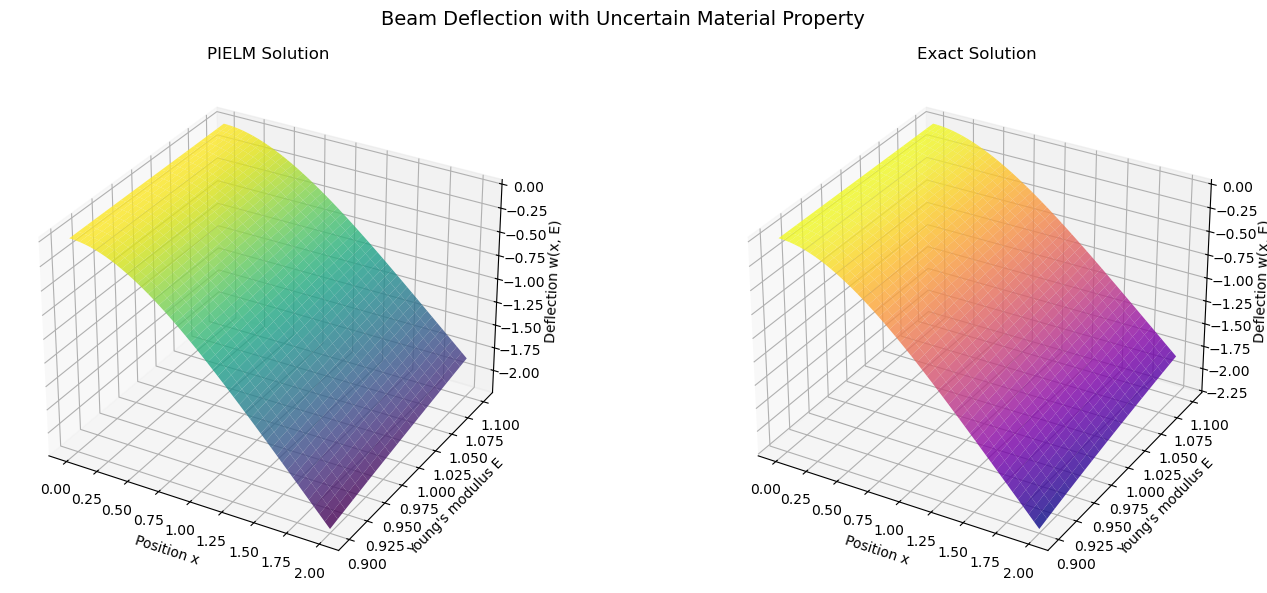


Comparison at the free end (x = L)
E value    PIELM        Exact        Error
------------------------------------------------------------
0.900    -2.201394    -2.222222    0.020829
0.950    -2.094077    -2.105263    0.011186
1.000    -2.012620    -2.000000    0.012620
1.050    -1.915573    -1.904762    0.010811
1.100    -1.823254    -1.818182    0.005072

Summary statistics:
Maximum deflection (PIELM): -2.201394
Maximum deflection (Exact): -2.222222
Mean absolute error: 0.002839
Total computation time: 0.4122 seconds


In [7]:
#finall
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# -----------------------------------------------------------------------------
# Physical parameters for the beam problem
# -----------------------------------------------------------------------------
I = 1.0               # Moment of inertia
Q = -1.0              # Distributed load (negative means downward)
L = 2.0               # Length of the beam
E_range = [0.9, 1.1]  # Young's modulus varies between these values

# -----------------------------------------------------------------------------
# Exact solution for validation
# -----------------------------------------------------------------------------
def analytical_solution(x, E):
    """Calculates the exact deflection of a cantilever beam with uniform load."""
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# -----------------------------------------------------------------------------
# Set up the Extreme Learning Machine
# -----------------------------------------------------------------------------
torch.manual_seed(42)          # For reproducible results
hidden_size = 50               # Number of neurons in the hidden layer

# Random weights and biases - these will stay fixed
W = torch.randn(2, hidden_size)  # Weight matrix (2 inputs × 50 neurons)
b = torch.randn(hidden_size)     # Bias vector (50 neurons)

def hidden_layer_2d_gaussian(xe):
    """Computes Gaussian activation for 2D input (x, E)."""
    linear = xe @ W + b        # Linear combination
    return torch.exp(-linear**2)  # Gaussian activation

# -----------------------------------------------------------------------------
# Create points where we'll enforce the physics
# -----------------------------------------------------------------------------
# Points inside the beam for the differential equation
n_x = 100    # Number of points along the beam length
n_E = 20     # Number of points for the material property

# Create a grid of points covering the entire domain
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')

# Flatten the grid into a list of points
X_flat = X.flatten().reshape(-1, 1)
E_flat = E.flatten().reshape(-1, 1)
xe_c = torch.cat([X_flat, E_flat], dim=1).requires_grad_(True)

# Points on the boundaries for the boundary conditions
n_E_bc = 5  # Number of E values on boundaries
E_bc = torch.linspace(E_range[0], E_range[1], n_E_bc).reshape(-1, 1)

# Left boundary (x = 0)
x0_points = torch.zeros(n_E_bc, 1)
xe_0 = torch.cat([x0_points, E_bc], dim=1).requires_grad_(True)

# Right boundary (x = L)
xL_points = torch.ones(n_E_bc, 1) * L
xe_L = torch.cat([xL_points, E_bc], dim=1).requires_grad_(True)

print("=" * 60)
print("Solving beam deflection with uncertain Young's modulus")
print("=" * 60)
print(f"Interior points: {n_x} × {n_E} = {n_x*n_E}")
print(f"Boundary points: {4 * n_E_bc} (4 conditions × {n_E_bc} E values)")
print(f"Material property range: E ∈ [{E_range[0]}, {E_range[1]}]")

# -----------------------------------------------------------------------------
# Build the matrix for the differential equation
# -----------------------------------------------------------------------------
start_time = default_timer()

# Get hidden layer outputs at all interior points
H_c = hidden_layer_2d_gaussian(xe_c)
A_cols = []  # Will store columns of our matrix

# For each hidden neuron, compute its contribution to the PDE
for j in range(hidden_size):
    # Get output of this specific neuron
    neuron_output = H_c[:, j:j+1]
    
    # Compute fourth derivative using automatic differentiation
    # First derivative
    grad1 = autograd.grad(neuron_output.sum(), xe_c, create_graph=True)[0]
    first_deriv = grad1[:, 0:1]
    
    # Second derivative
    grad2 = autograd.grad(first_deriv.sum(), xe_c, create_graph=True)[0]
    second_deriv = grad2[:, 0:1]
    
    # Third derivative
    grad3 = autograd.grad(second_deriv.sum(), xe_c, create_graph=True)[0]
    third_deriv = grad3[:, 0:1]
    
    # Fourth derivative
    grad4 = autograd.grad(third_deriv.sum(), xe_c, create_graph=True)[0]
    fourth_deriv = grad4[:, 0:1]
    
    A_cols.append(fourth_deriv)

# Combine all columns and apply the physics: E*I*w'''' = Q
E_values = xe_c[:, 1:2]  # Extract the E values
w_xxxx = torch.hstack(A_cols)  # Stack all fourth derivatives
A = E_values * I * w_xxxx  # This is our physics matrix

# Add a column of zeros for the bias term (ß₀)
# The bias doesn't appear in derivatives since derivative of constant is zero
A_aug = torch.hstack([A, torch.zeros(n_x * n_E, 1)])

# Right-hand side: the load Q (constant for all points)
b_pde = Q * torch.ones(n_x * n_E, 1)

# -----------------------------------------------------------------------------
# Build the boundary condition equations
# -----------------------------------------------------------------------------
def build_boundary_row(xe_points, derivative_order):
    """Creates one row of the boundary condition matrix."""
    H = hidden_layer_2d_gaussian(xe_points)
    num_points = xe_points.shape[0]
    row_parts = []
    
    for j in range(hidden_size):
        neuron_output = H[:, j:j+1]
        
        if derivative_order == 0:
            # Dirichlet condition: use the function value
            row_parts.append(neuron_output)
        else:
            # Neumann-type condition: compute derivatives
            current = neuron_output
            for _ in range(derivative_order):
                grad = autograd.grad(current.sum(), xe_points, create_graph=True)[0]
                current = grad[:, 0:1]  # Derivative with respect to x
            row_parts.append(current)
    
    # Add the bias term column
    if derivative_order == 0:
        bias_col = torch.ones(num_points, 1)  # For Dirichlet: B[1] = 1
    else:
        bias_col = torch.zeros(num_points, 1)  # For Neumann: B[1] = 0
    
    return torch.hstack([torch.hstack(row_parts), bias_col])

# Collect all boundary conditions
boundary_rows = []

# Left end conditions (x = 0)
boundary_rows.append(build_boundary_row(xe_0, 0))  # w(0, E) = 0
boundary_rows.append(build_boundary_row(xe_0, 1))  # w'(0, E) = 0

# Right end conditions (x = L)
boundary_rows.append(build_boundary_row(xe_L, 2))  # w''(L, E) = 0
boundary_rows.append(build_boundary_row(xe_L, 3))  # w'''(L, E) = 0

# Stack all boundary rows into one matrix
C_aug = torch.vstack(boundary_rows)
d = torch.zeros(4 * n_E_bc, 1)  # All boundary conditions are zero

print(f"\nSystem has {C_aug.shape[0]} boundary equations")
print(f"Matrix sizes: A_aug {A_aug.shape}, C_aug {C_aug.shape}")

# -----------------------------------------------------------------------------
# Solve the constrained optimization problem
# -----------------------------------------------------------------------------
# Transpose for the normal equations
A_T_aug = A_aug.T
C_T_aug = C_aug.T

# Total size: hidden neurons + bias + Lagrange multipliers
total_size = hidden_size + 1 + C_aug.shape[0]

# Build the KKT (Karush-Kuhn-Tucker) matrix
KKT = torch.zeros(total_size, total_size)

# Top-left: A^T A (minimize PDE residual)
KKT[:hidden_size+1, :hidden_size+1] = A_T_aug @ A_aug

# Off-diagonals: boundary constraints
KKT[:hidden_size+1, hidden_size+1:] = C_T_aug
KKT[hidden_size+1:, :hidden_size+1] = C_aug

# Right-hand side
rhs = torch.vstack([A_T_aug @ b_pde, d])

# Add small regularization for numerical stability
regularization = 1e-8 * torch.trace(A_T_aug @ A_aug) / (hidden_size + 1)
KKT[:hidden_size+1, :hidden_size+1] += regularization * torch.eye(hidden_size + 1)

# Solve the linear system
solution = torch.linalg.solve(KKT, rhs)

# Extract the solution: β weights and bias term
beta_with_bias = solution[:hidden_size+1]
beta = beta_with_bias[:hidden_size]      # Weights for hidden neurons
beta_0 = beta_with_bias[hidden_size:].item()  # Constant bias term

print(f"\nComputation time: {default_timer() - start_time:.4f} seconds")
print(f"Bias term ß₀ = {beta_0:.6e}")

# -----------------------------------------------------------------------------
# Make predictions on a new grid
# -----------------------------------------------------------------------------
n_pred_x = 50
n_pred_E = 20

# Create prediction grid
x_pred_grid = torch.linspace(0, L, n_pred_x)
E_pred_grid = torch.linspace(E_range[0], E_range[1], n_pred_E)
X_pred, E_pred = torch.meshgrid(x_pred_grid, E_pred_grid, indexing='ij')

# Flatten for evaluation
X_pred_flat = X_pred.flatten().reshape(-1, 1)
E_pred_flat = E_pred.flatten().reshape(-1, 1)
xe_pred = torch.cat([X_pred_flat, E_pred_flat], dim=1)

# Compute PIELM prediction: w(x,E) = Σ β_j h_j(x,E) + ß₀
H_pred = hidden_layer_2d_gaussian(xe_pred)
w_pred_flat = H_pred @ beta + beta_0
w_pred = w_pred_flat.reshape(n_pred_x, n_pred_E)

# Compare with exact solution
w_exact = analytical_solution(X_pred, E_pred)
error = torch.abs(w_pred - w_exact)

# Calculate relative error
max_w = torch.max(torch.abs(w_exact))
if max_w > 0:
    rel_error = torch.mean(error) / max_w
else:
    rel_error = torch.mean(error)

print(f"\nMean relative error: {rel_error.item()*100:.4f}%")
print(f"Maximum error: {torch.max(error).item():.6f}")

# -----------------------------------------------------------------------------
# Create visualizations
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(15, 6))

# PIELM prediction
ax1 = fig.add_subplot(121, projection='3d')
surface1 = ax1.plot_surface(X_pred.detach().numpy(), E_pred.detach().numpy(), 
                           w_pred.detach().numpy(), cmap='viridis', alpha=0.8)
ax1.set_xlabel('Position x')
ax1.set_ylabel('Young\'s modulus E')
ax1.set_zlabel('Deflection w(x, E)')
ax1.set_title('PIELM Solution')

# Exact solution
ax2 = fig.add_subplot(122, projection='3d')
surface2 = ax2.plot_surface(X_pred.detach().numpy(), E_pred.detach().numpy(), 
                           w_exact.detach().numpy(), cmap='plasma', alpha=0.8)
ax2.set_xlabel('Position x')
ax2.set_ylabel('Young\'s modulus E')
ax2.set_zlabel('Deflection w(x, E)')
ax2.set_title('Exact Solution')

plt.suptitle('Beam Deflection with Uncertain Material Property', fontsize=14)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Print detailed results
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("Comparison at the free end (x = L)")
print("=" * 60)
print("E value    PIELM        Exact        Error")
print("-" * 60)

# Test at several E values
E_test = torch.linspace(E_range[0], E_range[1], 5)
for E_val in E_test:
    # Find closest grid point
    E_idx = torch.argmin(torch.abs(E_pred_grid - E_val))
    L_idx = torch.argmin(torch.abs(x_pred_grid - L))
    
    pielm_val = w_pred[L_idx, E_idx].item()
    exact_val = analytical_solution(torch.tensor([[L]]), torch.tensor([[E_val]])).item()
    err = abs(pielm_val - exact_val)
    
    print(f"{E_val:.3f}    {pielm_val:8.6f}    {exact_val:8.6f}    {err:8.6f}")

print(f"\nSummary statistics:")
print(f"Maximum deflection (PIELM): {torch.min(w_pred).item():.6f}")
print(f"Maximum deflection (Exact): {torch.min(w_exact).item():.6f}")
print(f"Mean absolute error: {torch.mean(error).item():.6f}")
print(f"Total computation time: {default_timer() - start_time:.4f} seconds")

2D PIELM: Solving w(x, E) with Gaussian activation + ß₀
Collocation grid: 100×20 = 2000 points
x range: [0, 2.0]
E range: [0.9, 1.1]
Activation: Gaussian (exp(-(Wx+b)^2))

Boundary conditions: 20 constraints
With ß₀ term: Augmented matrices include bias column
Training time: 0.2558 s

ß₀ (output bias) value: -4.247729e+00

Relative error: 6.31e-04
Relative error percentage: 0.0631%


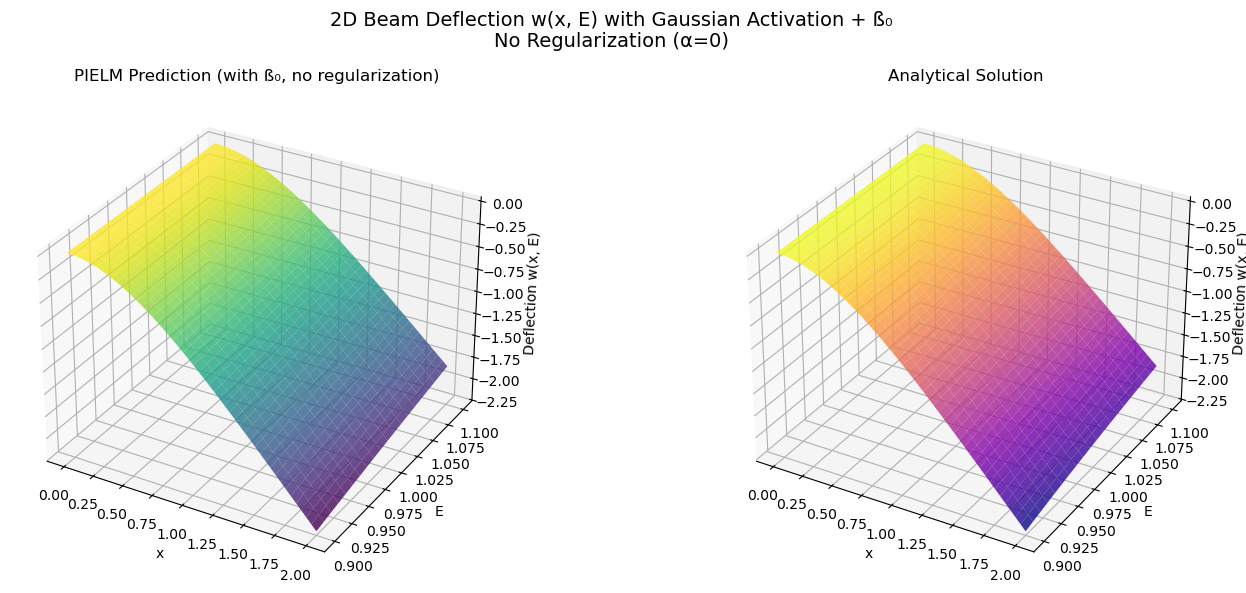


KEY RESULTS (Gaussian Activation with ß₀, No Regularization)
E		PIELM w(L,E)	Exact w(L,E)	Error
------------------------------------------------------------
0.900	-2.211871	-2.222222	0.010352
0.950	-2.100547	-2.105263	0.004716
1.000	-2.014855	-2.000000	0.014855
1.050	-1.911638	-1.904762	0.006876
1.100	-1.812552	-1.818182	0.005630

Max deflection PIELM: -2.211871
Max deflection Exact: -2.222222
Mean absolute error: 0.001402
Max absolute error: 0.010352
Training time: 0.4284 s
ß₀ value: -4.247729e+00


In [8]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS WITH UNCERTAIN E
# =============================================================================
I = 1.0
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]  # E ∈ [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION w(x, E)
# =============================================================================
def analytical_solution(x, E):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# 2D PIELM SETUP WITH GAUSSIAN ACTIVATION
# =============================================================================
torch.manual_seed(42)
hidden_size = 50  # Increased for 2D problem
W = torch.randn(2, hidden_size)  # 2 input features (x, E) × hidden_size
b = torch.randn(hidden_size)

def hidden_layer_2d_gaussian(xe):
    """Hidden layer for 2D input [x, E] with Gaussian activation"""
    return torch.exp(-(xe @ W + b)**2)  # Gaussian activation

# =============================================================================
# CREATE 2D COLLOCATION GRID (x, E)
# =============================================================================
n_x = 100   # Points in x direction
n_E = 20    # Points in E direction

# Create 2D grid
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)

# Create ALL combinations using meshgrid
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')

# Flatten for neural network input
X_flat = X.flatten().reshape(-1, 1)
E_flat = E.flatten().reshape(-1, 1)
xe_c = torch.cat([X_flat, E_flat], dim=1).requires_grad_(True)

# Boundary points (for x=0 and x=L, with E varying)
n_E_bc = 5
E_bc = torch.linspace(E_range[0], E_range[1], n_E_bc).reshape(-1, 1)

# Left boundary (x=0) for various E
x0_points = torch.zeros(n_E_bc, 1)
xe_0 = torch.cat([x0_points, E_bc], dim=1).requires_grad_(True)

# Right boundary (x=L) for various E  
xL_points = torch.ones(n_E_bc, 1) * L
xe_L = torch.cat([xL_points, E_bc], dim=1).requires_grad_(True)

print("=" * 60)
print("2D PIELM: Solving w(x, E) with Gaussian activation + ß₀")
print("=" * 60)
print(f"Collocation grid: {n_x}×{n_E} = {n_x*n_E} points")
print(f"x range: [0, {L}]")
print(f"E range: [{E_range[0]}, {E_range[1]}]")
print(f"Activation: Gaussian (exp(-(Wx+b)^2))")

# =============================================================================
# BUILD PDE MATRIX A (for 2D problem)
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_2d_gaussian(xe_c)  # Shape: (n_x*n_E, hidden_size)
A_cols = []

# Create columns for PDE matrix (Equation 40 in PDF)
for j in range(hidden_size):
    wj = H_c[:, j:j+1]
    
    # Compute ∂⁴w/∂x⁴ (derivative with respect to x only)
    grad1 = autograd.grad(wj.sum(), xe_c, create_graph=True)[0]
    dw_dx = grad1[:, 0:1]
    
    grad2 = autograd.grad(dw_dx.sum(), xe_c, create_graph=True)[0]
    d2w_dx2 = grad2[:, 0:1]
    
    grad3 = autograd.grad(d2w_dx2.sum(), xe_c, create_graph=True)[0]
    d3w_dx3 = grad3[:, 0:1]
    
    grad4 = autograd.grad(d3w_dx3.sum(), xe_c, create_graph=True)[0]
    d4w_dx4 = grad4[:, 0:1]
    
    A_cols.append(d4w_dx4)

# Include E values in the PDE
E_values = xe_c[:, 1:2]  # Shape: (n_x*n_E, 1)
w_xxxx = torch.hstack(A_cols)
A = E_values * I * w_xxxx  # Interior feature matrix H_r (Eq. 40)

# Add ZERO column for ß₀ (c term) - since c doesn't appear in interior PDE
# According to Eq. 58 in PDF: \tilde{H}_r = [H_r, 0]
A_aug = torch.hstack([A, torch.zeros(n_x * n_E, 1)])  # Augmented interior matrix

b_pde = Q * torch.ones(n_x * n_E, 1)  # Source term f_r (Eq. 41)

# =============================================================================
# BOUNDARY CONDITIONS (for each E value) WITH ß₀ TERM
# =============================================================================
def bc_row_2d_gaussian(xe_points, order):
    """Compute boundary condition row for 2D input with Gaussian activation"""
    H = hidden_layer_2d_gaussian(xe_points)
    n_points = xe_points.shape[0]
    row = []
    
    for j in range(hidden_size):
        w = H[:, j:j+1]
        
        if order == 0:
            row.append(w)
        else:
            current = w
            for _ in range(order):
                grad = autograd.grad(current.sum(), xe_points, create_graph=True)[0]
                current = grad[:, 0:1]  # Derivative w.r.t x only
            row.append(current)
    
    # Add column for ß₀ (c term) - boundary operator applied to constant
    # For Dirichlet: B[1] = 1, For Neumann: B[1] = 0
    if order == 0:
        # Dirichlet: ß₀ coefficient is 1 (Eq. 54 in PDF)
        c_col = torch.ones(n_points, 1)
    else:
        # Neumann or higher: ß₀ coefficient is 0
        c_col = torch.zeros(n_points, 1)
    
    return torch.hstack([torch.hstack(row), c_col])  # Augmented boundary row

# Boundary condition rows with ß₀ term
C_rows = []

# w(0, E) = 0 (Dirichlet)
C_rows.append(bc_row_2d_gaussian(xe_0, 0))
# w'(0, E) = 0 (Neumann)
C_rows.append(bc_row_2d_gaussian(xe_0, 1))
# w''(L, E) = 0 (2nd order Neumann)
C_rows.append(bc_row_2d_gaussian(xe_L, 2))
# w'''(L, E) = 0 (3rd order Neumann)
C_rows.append(bc_row_2d_gaussian(xe_L, 3))

C_aug = torch.vstack(C_rows)  # Augmented boundary matrix \tilde{H}_b (Eq. 55)
d = torch.zeros(4 * n_E_bc, 1)  # Boundary data g_b (Eq. 52)

print(f"\nBoundary conditions: {C_aug.shape[0]} constraints")
print(f"With ß₀ term: Augmented matrices include bias column")

# =============================================================================
# KKT SYSTEM WITH ß₀ (Augmented system, Eq. 63) - NO REGULARIZATION
# =============================================================================
A_T_aug = A_aug.T
C_T_aug = C_aug.T

# Augmented parameter vector: [β₁, β₂, ..., β_L, ß₀]^T (Eq. 56)
kk_size = hidden_size + 1 + C_aug.shape[0]  # hidden_size + ß₀ + Lagrange multipliers

KKT = torch.zeros(kk_size, kk_size)

# Top-left block: A^T A (interior normal equations)
KKT[:hidden_size+1, :hidden_size+1] = A_T_aug @ A_aug

# Top-right block: C^T (boundary constraints)
KKT[:hidden_size+1, hidden_size+1:] = C_T_aug

# Bottom-left block: C (boundary constraints)
KKT[hidden_size+1:, :hidden_size+1] = C_aug

# Right-hand side
rhs = torch.vstack([A_T_aug @ b_pde, d])

# NO REGULARIZATION - removing alpha term
# This is the original KKT system without Tikhonov regularization

# Solve KKT system
solution = torch.linalg.solve(KKT, rhs)
beta_with_bias = solution[:hidden_size+1]  # [β₁, β₂, ..., β_L, ß₀]^T
beta = beta_with_bias[:hidden_size]  # Just the β weights
beta_0 = beta_with_bias[hidden_size:].item()  # ß₀ (scalar bias)

print(f"Training time: {default_timer() - t0:.4f} s")
print(f"\nß₀ (output bias) value: {beta_0:.6e}")

# =============================================================================
# PREDICTION ON 2D GRID WITH ß₀
# =============================================================================
n_pred_x = 50
n_pred_E = 20

x_pred_grid = torch.linspace(0, L, n_pred_x)
E_pred_grid = torch.linspace(E_range[0], E_range[1], n_pred_E)
X_pred, E_pred = torch.meshgrid(x_pred_grid, E_pred_grid, indexing='ij')

X_pred_flat = X_pred.flatten().reshape(-1, 1)
E_pred_flat = E_pred.flatten().reshape(-1, 1)
xe_pred = torch.cat([X_pred_flat, E_pred_flat], dim=1)

# Prediction with ß₀: ŵ(x,E) = Σ β_j h_j(x,E) + ß₀ (Eq. 34)
H_pred = hidden_layer_2d_gaussian(xe_pred)
w_pred_flat = H_pred @ beta + beta_0  # Add ß₀ bias term
w_pred = w_pred_flat.reshape(n_pred_x, n_pred_E)

# Analytical solution
w_exact = analytical_solution(X_pred, E_pred)

# Error
error = torch.abs(w_pred - w_exact)

# Safe relative error
max_abs_w_exact = torch.max(torch.abs(w_exact))
rel_error = torch.mean(error) / max_abs_w_exact if max_abs_w_exact > 0 else torch.mean(error)
rel_error_percentage = rel_error * 100

print(f"\nRelative error: {rel_error.item():.2e}")
print(f"Relative error percentage: {rel_error_percentage.item():.4f}%")

# =============================================================================
# 3D PLOTS
# =============================================================================
fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X_pred.detach().numpy(), E_pred.detach().numpy(), 
                        w_pred.detach().numpy(), cmap='viridis', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('E')
ax1.set_zlabel('Deflection w(x, E)')
ax1.set_title('PIELM Prediction (with ß₀, no regularization)')

ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X_pred.detach().numpy(), E_pred.detach().numpy(), 
                        w_exact.detach().numpy(), cmap='plasma', alpha=0.8)
ax2.set_xlabel('x')
ax2.set_ylabel('E')
ax2.set_zlabel('Deflection w(x, E)')
ax2.set_title('Analytical Solution')

plt.suptitle(f'2D Beam Deflection w(x, E) with Gaussian Activation + ß₀\nNo Regularization (α=0)', fontsize=14)
plt.tight_layout()
plt.show()

# =============================================================================
# PRINT KEY RESULTS
# =============================================================================
print("\n" + "=" * 60)
print("KEY RESULTS (Gaussian Activation with ß₀, No Regularization)")
print("=" * 60)
print("E\t\tPIELM w(L,E)\tExact w(L,E)\tError")
print("-" * 60)

E_test = torch.linspace(E_range[0], E_range[1], 5)
for E_val in E_test:
    E_idx = torch.argmin(torch.abs(E_pred_grid - E_val))
    L_idx = torch.argmin(torch.abs(x_pred_grid - L))
    w_pielm = w_pred[L_idx, E_idx].item()
    w_exact_val = analytical_solution(torch.tensor([[L]]), torch.tensor([[E_val]])).item()
    print(f"{E_val:.3f}\t{w_pielm:.6f}\t{w_exact_val:.6f}\t{abs(w_pielm - w_exact_val):.6f}")

print(f"\nMax deflection PIELM: {torch.min(w_pred).item():.6f}")
print(f"Max deflection Exact: {torch.min(w_exact).item():.6f}")
print(f"Mean absolute error: {torch.mean(error).item():.6f}")
print(f"Max absolute error: {torch.max(error).item():.6f}")
print(f"Training time: {default_timer() - t0:.4f} s")
print(f"ß₀ value: {beta_0:.6e}")

Bias term ß₀ = -4.822815e+00
Computation time: 0.8434 seconds
Mean absolute error: 0.020779
Max error: 0.111886


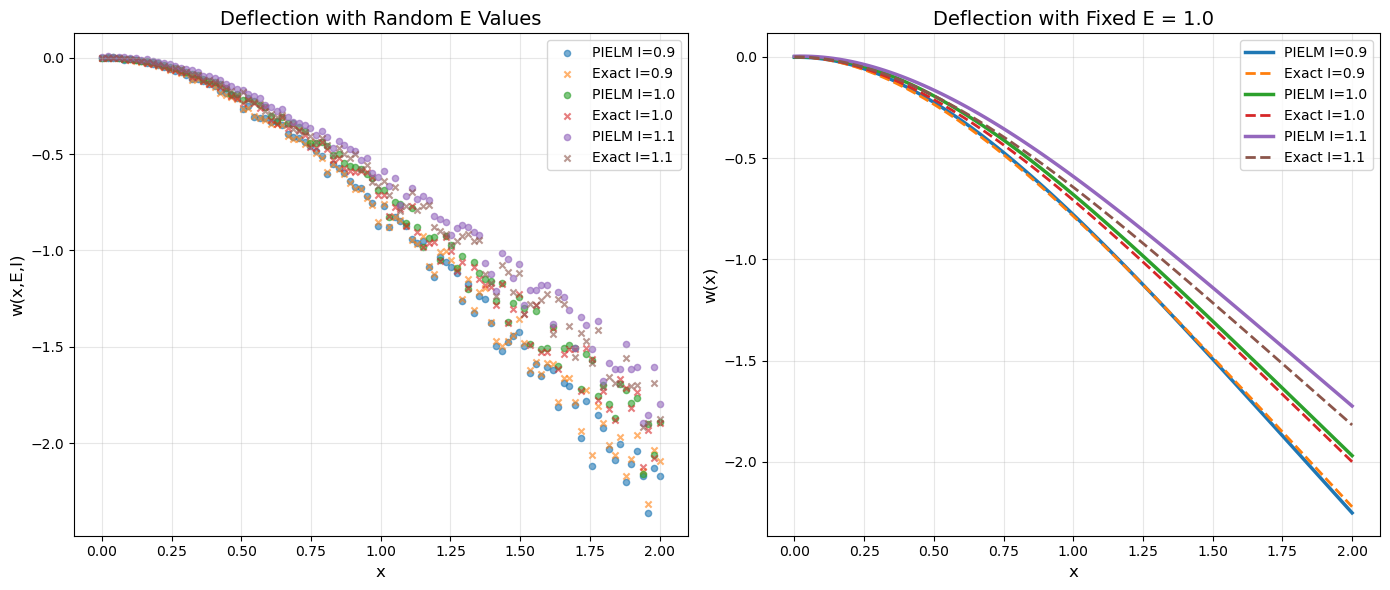

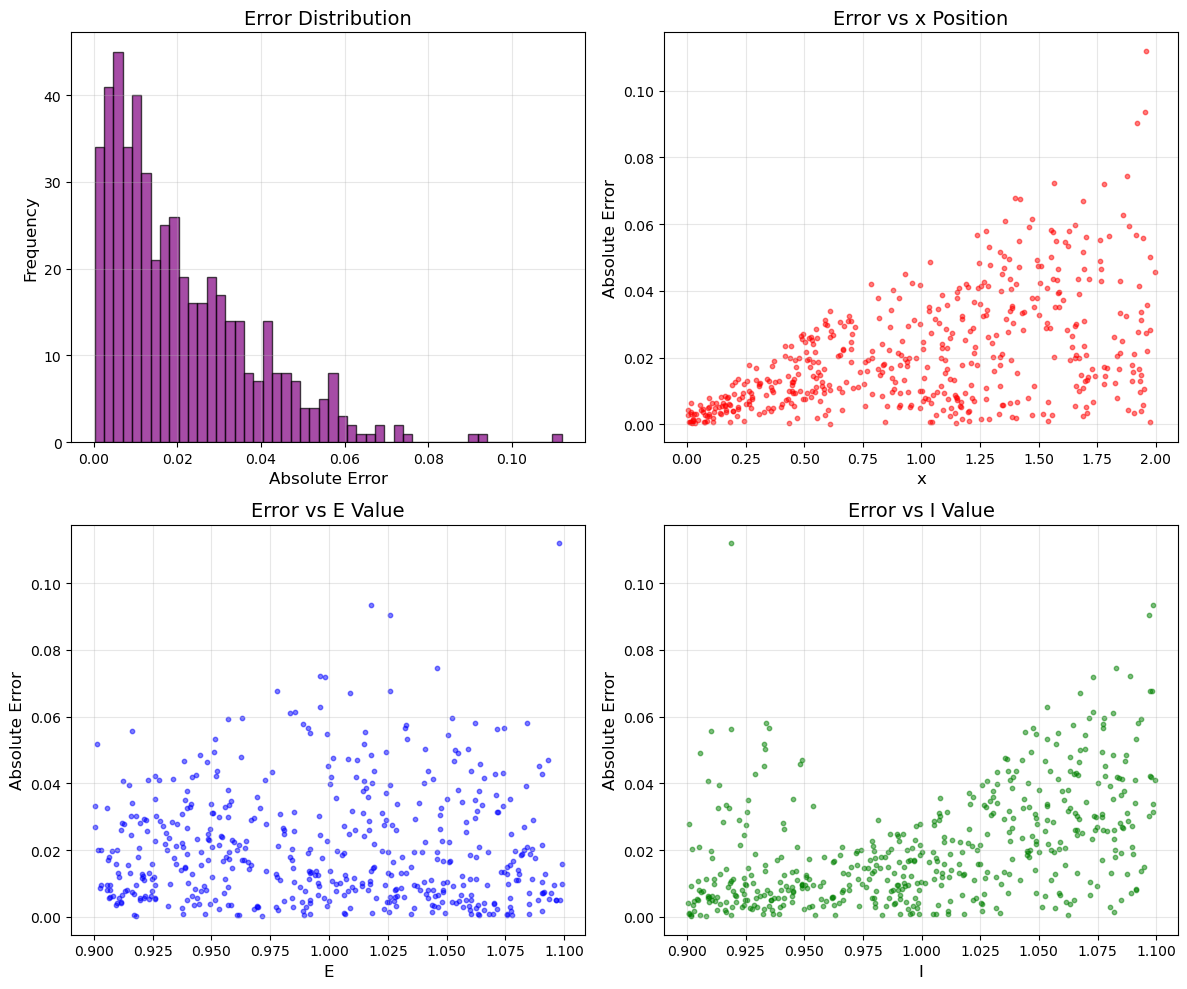


COMPREHENSIVE STATISTICS
Bias term (ß₀): -4.822815e+00
Computation time: 1.0863 seconds
Mean absolute error: 0.020779
Median absolute error: 0.016507
Max absolute error: 0.111886
Relative L2 error: 0.027121
Standard deviation of error: 0.017261
Error at x=0 (should be 0): 2.623325e-03
Error at x=L (should be 0): 4.581559e-02

BOUNDARY CONDITION CHECK:
----------------------------------------
At x=0: PIELM=1.516342e-04, Exact=-0.000000e+00, Error=1.516342e-04
At x=L: PIELM=-1.969715e+00, Exact=-2.000000e+00, Error=3.028488e-02


In [4]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer

# Physical parameters
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# ELM setup
torch.manual_seed(42)
hidden_size = 100  # Increased for better accuracy
W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer_3d_gaussian(xei):
    linear = xei @ W + b
    return torch.exp(-linear**2)

# Random PDE points
n_pde = 3000  # Increased for better accuracy
x_pde = torch.rand(n_pde, 1) * L
E_pde = torch.rand(n_pde, 1) * (E_range[1] - E_range[0]) + E_range[0]
I_pde = torch.rand(n_pde, 1) * (I_range[1] - I_range[0]) + I_range[0]

xe_pde = torch.cat([x_pde, E_pde, I_pde], dim=1).requires_grad_(True)

# Boundary points (random)
n_bc = 500
E_bc = torch.rand(n_bc, 1) * (E_range[1] - E_range[0]) + E_range[0]
I_bc = torch.rand(n_bc, 1) * (I_range[1] - I_range[0]) + I_range[0]

x0_bc = torch.zeros(n_bc, 1)
xL_bc = torch.ones(n_bc, 1) * L

xe_0 = torch.cat([x0_bc, E_bc, I_bc], dim=1).requires_grad_(True)
xe_L = torch.cat([xL_bc, E_bc, I_bc], dim=1).requires_grad_(True)

# Build PDE matrix A
start_time = default_timer()

H_pde = hidden_layer_3d_gaussian(xe_pde)
A_cols = []

for j in range(hidden_size):
    neuron_output = H_pde[:, j:j+1]

    grad1 = autograd.grad(neuron_output.sum(), xe_pde, create_graph=True)[0]
    first_deriv = grad1[:, 0:1]

    grad2 = autograd.grad(first_deriv.sum(), xe_pde, create_graph=True)[0]
    second_deriv = grad2[:, 0:1]

    grad3 = autograd.grad(second_deriv.sum(), xe_pde, create_graph=True)[0]
    third_deriv = grad3[:, 0:1]

    grad4 = autograd.grad(third_deriv.sum(), xe_pde, create_graph=True)[0]
    fourth_deriv = grad4[:, 0:1]

    A_cols.append(fourth_deriv)

E_vals = xe_pde[:, 1:2]
I_vals = xe_pde[:, 2:3]

w_xxxx = torch.hstack(A_cols)
A = E_vals * I_vals * w_xxxx

A_aug = torch.hstack([A, torch.zeros(n_pde, 1)])
b_pde = Q * torch.ones(n_pde, 1)

# Build boundary matrix C
def build_boundary_row(xe_points, derivative_order):
    H = hidden_layer_3d_gaussian(xe_points)
    num_points = xe_points.shape[0]
    row_parts = []

    for j in range(hidden_size):
        neuron_output = H[:, j:j+1]

        if derivative_order == 0:
            row_parts.append(neuron_output)
        else:
            current = neuron_output
            for _ in range(derivative_order):
                grad = autograd.grad(current.sum(), xe_points, create_graph=True)[0]
                current = grad[:, 0:1]
            row_parts.append(current)

    if derivative_order == 0:
        bias_col = torch.ones(num_points, 1)
    else:
        bias_col = torch.zeros(num_points, 1)

    return torch.hstack([torch.hstack(row_parts), bias_col])

boundary_rows = []
boundary_rows.append(build_boundary_row(xe_0, 0))
boundary_rows.append(build_boundary_row(xe_0, 1))
boundary_rows.append(build_boundary_row(xe_L, 2))
boundary_rows.append(build_boundary_row(xe_L, 3))

C_aug = torch.vstack(boundary_rows)
d = torch.zeros(4 * n_bc, 1)

# Solve for β
A_T_aug = A_aug.T
C_T_aug = C_aug.T

total_size = hidden_size + 1 + C_aug.shape[0]
KKT = torch.zeros(total_size, total_size)

KKT[:hidden_size+1, :hidden_size+1] = A_T_aug @ A_aug
KKT[:hidden_size+1, hidden_size+1:] = C_T_aug
KKT[hidden_size+1:, :hidden_size+1] = C_aug

rhs = torch.vstack([A_T_aug @ b_pde, d])

regularization = 1e-9 * torch.trace(A_T_aug @ A_aug) / (hidden_size + 1)  # Reduced
KKT[:hidden_size+1, :hidden_size+1] += regularization * torch.eye(hidden_size + 1)

solution = torch.linalg.solve(KKT, rhs)

beta_with_bias = solution[:hidden_size+1]
beta = beta_with_bias[:hidden_size]
beta_0 = beta_with_bias[hidden_size:].item()

print(f"Bias term ß₀ = {beta_0:.6e}")
print(f"Computation time: {default_timer() - start_time:.4f} seconds")

# ============================================
# PREDICTION AND PLOTTING WITH CONSISTENT E
# ============================================

# I values to plot (choose consistent with your problem)
I_values_to_plot = [0.9, 1.0, 1.1]

# Error calculation on random points
n_error = 500
x_error = torch.rand(n_error, 1) * L
E_error = torch.rand(n_error, 1) * (E_range[1] - E_range[0]) + E_range[0]
I_error = torch.rand(n_error, 1) * (I_range[1] - I_range[0]) + I_range[0]

xe_error = torch.cat([x_error, E_error, I_error], dim=1)
H_error = hidden_layer_3d_gaussian(xe_error)
w_pred_error = H_error @ beta + beta_0
w_exact_error = analytical_solution(x_error, E_error, I_error)

error = torch.abs(w_pred_error - w_exact_error)
print(f"Mean absolute error: {torch.mean(error).item():.6f}")
print(f"Max error: {torch.max(error).item():.6f}")

# ============================================
# PLOT 1: With random E values (showing spread)
# ============================================
plt.figure(figsize=(14, 6))

# Subplot 1: Random E values
plt.subplot(1, 2, 1)

n_points = 100
x_vals = torch.linspace(0, L, n_points).reshape(-1, 1)

for I_val in I_values_to_plot:
    # Random E values for each point
    E_random = torch.rand(n_points, 1) * (E_range[1] - E_range[0]) + E_range[0]
    I_fixed = torch.ones(n_points, 1) * I_val
    
    xe_random = torch.cat([x_vals, E_random, I_fixed], dim=1)
    
    # PIELM prediction
    H_random = hidden_layer_3d_gaussian(xe_random)
    w_pred_random = H_random @ beta + beta_0
    
    # Exact solution
    w_exact_random = analytical_solution(x_vals, E_random, I_fixed)
    
    # Plot
    x_plot = x_vals.detach().numpy().flatten()
    w_pred_plot = w_pred_random.detach().numpy().flatten()
    w_exact_plot = w_exact_random.detach().numpy().flatten()
    
    # Sort by x for cleaner plotting
    sorted_indices = np.argsort(x_plot)
    x_sorted = x_plot[sorted_indices]
    w_pred_sorted = w_pred_plot[sorted_indices]
    w_exact_sorted = w_exact_plot[sorted_indices]
    
    plt.scatter(x_sorted, w_pred_sorted, s=20, alpha=0.6, label=f'PIELM I={I_val}')
    plt.scatter(x_sorted, w_exact_sorted, s=20, alpha=0.6, marker='x', label=f'Exact I={I_val}')

plt.title("Deflection with Random E Values", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("w(x,E,I)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper right')

# ============================================
# PLOT 2: With fixed E value (clean comparison)
# ============================================
plt.subplot(1, 2, 2)

# Fixed E value (use middle of range)
E_fixed = (E_range[0] + E_range[1]) / 2  # This gives 1.0 for [0.9, 1.1]

for I_val in I_values_to_plot:
    # Fixed E values for all points
    E_fixed_tensor = torch.ones(n_points, 1) * E_fixed
    I_fixed_tensor = torch.ones(n_points, 1) * I_val
    
    xe_fixed = torch.cat([x_vals, E_fixed_tensor, I_fixed_tensor], dim=1)
    
    # PIELM prediction
    H_fixed = hidden_layer_3d_gaussian(xe_fixed)
    w_pred_fixed = H_fixed @ beta + beta_0
    
    # Exact solution
    w_exact_fixed = analytical_solution(x_vals, E_fixed_tensor, I_fixed_tensor)
    
    # Plot as lines
    x_plot = x_vals.detach().numpy().flatten()
    w_pred_plot = w_pred_fixed.detach().numpy().flatten()
    w_exact_plot = w_exact_fixed.detach().numpy().flatten()
    
    plt.plot(x_plot, w_pred_plot, linewidth=2.5, label=f'PIELM I={I_val}')
    plt.plot(x_plot, w_exact_plot, '--', linewidth=2, label=f'Exact I={I_val}')

plt.title(f"Deflection with Fixed E = {E_fixed:.1f}", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("w(x)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

# ============================================
# PLOT 3: Error analysis
# ============================================
plt.figure(figsize=(12, 10))

# Subplot 1: Error distribution
plt.subplot(2, 2, 1)
error_np = error.detach().numpy().flatten()
plt.hist(error_np, bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.title("Error Distribution", fontsize=14)
plt.xlabel("Absolute Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, alpha=0.3)

# Subplot 2: Error vs x
plt.subplot(2, 2, 2)
plt.scatter(x_error.detach().numpy().flatten(), 
            error.detach().numpy().flatten(), 
            alpha=0.5, s=10, color='red')
plt.title("Error vs x Position", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("Absolute Error", fontsize=12)
plt.grid(True, alpha=0.3)

# Subplot 3: Error vs E
plt.subplot(2, 2, 3)
plt.scatter(E_error.detach().numpy().flatten(), 
            error.detach().numpy().flatten(), 
            alpha=0.5, s=10, color='blue')
plt.title("Error vs E Value", fontsize=14)
plt.xlabel("E", fontsize=12)
plt.ylabel("Absolute Error", fontsize=12)
plt.grid(True, alpha=0.3)

# Subplot 4: Error vs I
plt.subplot(2, 2, 4)
plt.scatter(I_error.detach().numpy().flatten(), 
            error.detach().numpy().flatten(), 
            alpha=0.5, s=10, color='green')
plt.title("Error vs I Value", fontsize=14)
plt.xlabel("I", fontsize=12)
plt.ylabel("Absolute Error", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Print comprehensive statistics
# ============================================
print("\n" + "="*60)
print("COMPREHENSIVE STATISTICS")
print("="*60)
print(f"Bias term (ß₀): {beta_0:.6e}")
print(f"Computation time: {default_timer() - start_time:.4f} seconds")
print(f"Mean absolute error: {torch.mean(error).item():.6f}")
print(f"Median absolute error: {torch.median(error).item():.6f}")
print(f"Max absolute error: {torch.max(error).item():.6f}")
print(f"Relative L2 error: {torch.norm(w_pred_error - w_exact_error) / torch.norm(w_exact_error):.6f}")
print(f"Standard deviation of error: {torch.std(error).item():.6f}")
print(f"Error at x=0 (should be 0): {torch.abs(w_pred_error[x_error < 0.01] - w_exact_error[x_error < 0.01]).mean().item():.6e}")
print(f"Error at x=L (should be 0): {torch.abs(w_pred_error[x_error > L-0.01] - w_exact_error[x_error > L-0.01]).mean().item():.6e}")
print("="*60)

# ============================================
# Additional diagnostic: Check boundary conditions
# ============================================
print("\nBOUNDARY CONDITION CHECK:")
print("-"*40)

# Test boundary conditions with fixed parameters
E_test = 1.0
I_test = 1.0

# x = 0
x0_test = torch.tensor([[0.0]])
E0_test = torch.tensor([[E_test]])
I0_test = torch.tensor([[I_test]])
xe0_test = torch.cat([x0_test, E0_test, I0_test], dim=1)
H0_test = hidden_layer_3d_gaussian(xe0_test)
w0_pred = (H0_test @ beta + beta_0).item()
w0_exact = analytical_solution(x0_test, E0_test, I0_test).item()
print(f"At x=0: PIELM={w0_pred:.6e}, Exact={w0_exact:.6e}, Error={abs(w0_pred-w0_exact):.6e}")

# x = L
xL_test = torch.tensor([[L]])
EL_test = torch.tensor([[E_test]])
IL_test = torch.tensor([[I_test]])
xeL_test = torch.cat([xL_test, EL_test, IL_test], dim=1)
HL_test = hidden_layer_3d_gaussian(xeL_test)
wL_pred = (HL_test @ beta + beta_0).item()
wL_exact = analytical_solution(xL_test, EL_test, IL_test).item()
print(f"At x=L: PIELM={wL_pred:.6e}, Exact={wL_exact:.6e}, Error={abs(wL_pred-wL_exact):.6e}")

In [2]:
pip install pyDOE2


Note: you may need to restart the kernel to use updated packages.


Bias term ß₀ = -3.878021e-01
Computation time: 1.8214 s
Mean absolute error: 0.014010
Max error: 0.052997

Mean Predicted: -0.789595, Exact: -0.802877
Variance Predicted: 0.418380, Exact: 0.412612


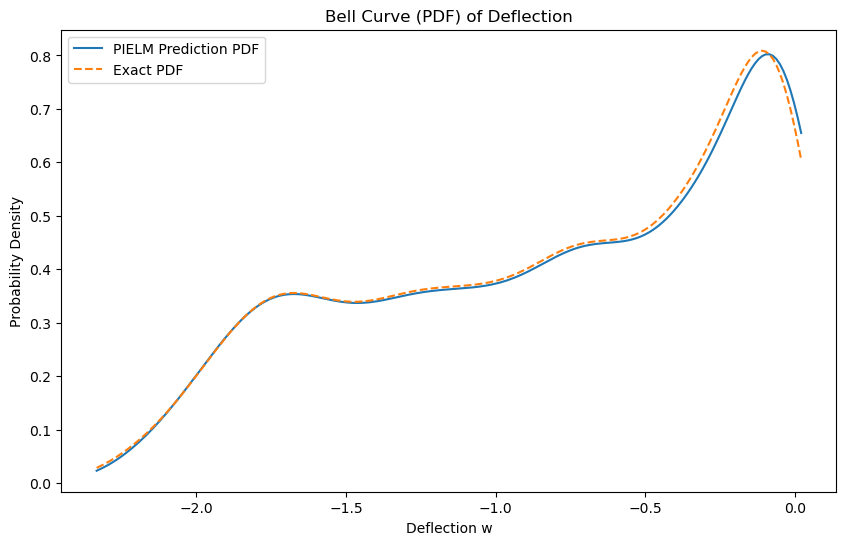

In [9]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer
from scipy.stats import gaussian_kde

# =========================================================
# Physical parameters
# =========================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =========================================================
# ELM setup
# =========================================================
torch.manual_seed(42)

hidden_size = 120
W = torch.randn(3, hidden_size, dtype=torch.float32)
b = torch.randn(hidden_size, dtype=torch.float32)

def hidden_layer(xei):
    return torch.tanh(xei @ W + b)

# =========================================================
# PDE collocation points (Monte Carlo)
# =========================================================
n_pde = 8000

x_pde = torch.rand(n_pde, 1, dtype=torch.float32) * L
E_pde = torch.rand(n_pde, 1, dtype=torch.float32) * (E_range[1]-E_range[0]) + E_range[0]
I_pde = torch.rand(n_pde, 1, dtype=torch.float32) * (I_range[1]-I_range[0]) + I_range[0]

xe_pde = torch.cat([x_pde, E_pde, I_pde], dim=1).requires_grad_(True)

# =========================================================
# Boundary points (Monte Carlo)
# =========================================================
n_bc = 1000

E_bc = torch.rand(n_bc, 1, dtype=torch.float32) * (E_range[1]-E_range[0]) + E_range[0]
I_bc = torch.rand(n_bc, 1, dtype=torch.float32) * (I_range[1]-I_range[0]) + I_range[0]

x0 = torch.zeros(n_bc, 1)
xL = torch.ones(n_bc, 1) * L

xe_0 = torch.cat([x0, E_bc, I_bc], dim=1).requires_grad_(True)
xe_L = torch.cat([xL, E_bc, I_bc], dim=1).requires_grad_(True)

# =========================================================
# Build PDE matrix A
# =========================================================
start_time = default_timer()

H_pde = hidden_layer(xe_pde)
A_cols = []

for j in range(hidden_size):
    h = H_pde[:, j:j+1]

    g1 = autograd.grad(h.sum(), xe_pde, create_graph=True)[0][:, 0:1]
    g2 = autograd.grad(g1.sum(), xe_pde, create_graph=True)[0][:, 0:1]
    g3 = autograd.grad(g2.sum(), xe_pde, create_graph=True)[0][:, 0:1]
    g4 = autograd.grad(g3.sum(), xe_pde, create_graph=True)[0][:, 0:1]

    A_cols.append(g4)

w_xxxx = torch.hstack(A_cols)
A = xe_pde[:, 1:2] * xe_pde[:, 2:3] * w_xxxx

A_aug = torch.hstack([A, torch.zeros(n_pde, 1)])
b_pde = Q * torch.ones(n_pde, 1)

# =========================================================
# Boundary condition matrix C
# =========================================================
def build_bc(xe, order):
    H = hidden_layer(xe)
    rows = []

    for j in range(hidden_size):
        h = H[:, j:j+1]
        for _ in range(order):
            h = autograd.grad(h.sum(), xe, create_graph=True)[0][:, 0:1]
        rows.append(h)

    bias = torch.ones(xe.shape[0], 1) if order == 0 else torch.zeros(xe.shape[0], 1)
    return torch.hstack([torch.hstack(rows), bias])

C = torch.vstack([
    build_bc(xe_0, 0),
    build_bc(xe_0, 1),
    build_bc(xe_L, 2),
    build_bc(xe_L, 3)
])

d = torch.zeros(4 * n_bc, 1)

# =========================================================
# Solve KKT system
# =========================================================
A_T = A_aug.T
C_T = C.T

size = hidden_size + 1 + C.shape[0]
KKT = torch.zeros(size, size)

KKT[:hidden_size+1, :hidden_size+1] = A_T @ A_aug
KKT[:hidden_size+1, hidden_size+1:] = C_T
KKT[hidden_size+1:, :hidden_size+1] = C

rhs = torch.vstack([A_T @ b_pde, d])

reg = 1e-8 * torch.trace(A_T @ A_aug) / (hidden_size + 1)
KKT[:hidden_size+1, :hidden_size+1] += reg * torch.eye(hidden_size + 1)

solution = torch.linalg.solve(KKT, rhs)

beta = solution[:hidden_size]
beta_0 = solution[hidden_size].item()

print(f"Bias term ß₀ = {beta_0:.6e}")
print(f"Computation time: {default_timer() - start_time:.4f} s")

# =========================================================
# Prediction (Monte Carlo)
# =========================================================
n_pred = 3000

x_pred = torch.rand(n_pred, 1, dtype=torch.float32) * L
E_pred = torch.rand(n_pred, 1, dtype=torch.float32) * (E_range[1]-E_range[0]) + E_range[0]
I_pred = torch.rand(n_pred, 1, dtype=torch.float32) * (I_range[1]-I_range[0]) + I_range[0]

xe_pred = torch.cat([x_pred, E_pred, I_pred], dim=1)

H_pred = hidden_layer(xe_pred)
w_pred = H_pred @ beta + beta_0
w_exact = analytical_solution(x_pred, E_pred, I_pred)

error = torch.abs(w_pred - w_exact)

print(f"Mean absolute error: {torch.mean(error).item():.6f}")
print(f"Max error: {torch.max(error).item():.6f}")

# =========================================================
# Mean and variance
w_pred_np = w_pred.detach().numpy().flatten()
w_exact_np = w_exact.detach().numpy().flatten()

mean_pred = np.mean(w_pred_np)
mean_exact = np.mean(w_exact_np)

var_pred = np.var(w_pred_np)
var_exact = np.var(w_exact_np)

print(f"\nMean Predicted: {mean_pred:.6f}, Exact: {mean_exact:.6f}")
print(f"Variance Predicted: {var_pred:.6f}, Exact: {var_exact:.6f}")

# =========================================================
# Plot Bell curves using KDE
kde_pred = gaussian_kde(w_pred_np)
kde_exact = gaussian_kde(w_exact_np)

xs = np.linspace(min(w_pred_np.min(), w_exact_np.min()),
                 max(w_pred_np.max(), w_exact_np.max()), 200)

plt.figure(figsize=(10, 6))
plt.plot(xs, kde_pred(xs), label="PIELM Prediction PDF")
plt.plot(xs, kde_exact(xs), label="Exact PDF", linestyle='--')
plt.title("Bell Curve (PDF) of Deflection")
plt.xlabel("Deflection w")
plt.ylabel("Probability Density")
plt.legend()
plt.show()


SOLVING BEAM DEFLECTION WITH UNCERTAIN YOUNG'S MODULUS
Interior points: 50 × 10 = 500
Material property range: E ∈ [0.9, 1.1]

COMPUTATION DETAILS:
System size: 71 × 71
Regularization parameter α = 6.79e-11
Bias term ß₀ = -1.518532e+03
Computation time: 0.0764 seconds

UNCERTAINTY PROPAGATION ANALYSIS
Monte Carlo samples: 5000
Mean tip deflection: -2.008563
Standard deviation: 0.112072
95% CI: [-2.228225, -1.788901]

MODEL ACCURACY:
Mean relative error: 0.2088%
Maximum absolute error: 0.016004


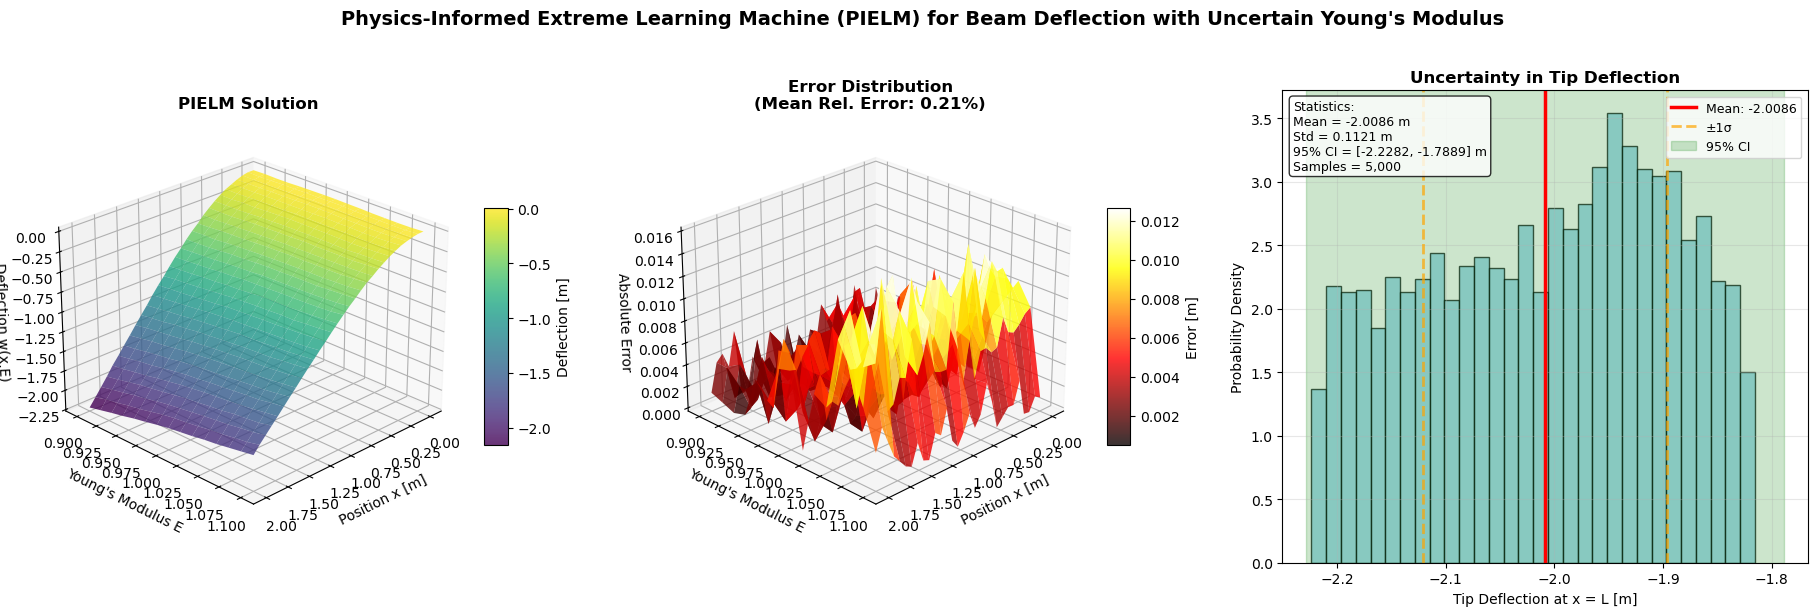


DETAILED VALIDATION AT SPECIFIC POINTS
E        x        PIELM        Exact        Error        Rel.Err.[%] 
----------------------------------------------------------------------
0.950    1.000    -0.743164    -0.745614    0.002450     0.329       
1.050    1.000    -0.682617    -0.674603    0.008014     1.188       
0.950    2.000    -2.100586    -2.105263    0.004677     0.222       
1.000    2.000    -1.997070    -2.000000    0.002930     0.146       
1.050    2.000    -1.916992    -1.904762    0.012230     0.642       

SUMMARY
PIELM Configuration:
  Hidden neurons: 50
  Collocation points: 500
  Boundary points: 20

Accuracy:
  Mean relative error: 0.2088%
  Max absolute error: 0.016004 m

Uncertainty Quantification:
  Tip deflection mean: -2.008563 m
  Tip deflection std: 0.112072 m
  Coefficient of variation: 5.58%

Computational Performance:
  Training time: 0.30 seconds
  KKT system size: 71 × 71


In [1]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer
from scipy.stats import qmc

# =============================================================================
# PHYSICAL PARAMETERS FOR THE BEAM PROBLEM
# =============================================================================
I = 1.0               # Moment of inertia
Q = -1.0              # Distributed load (negative means downward)
L = 2.0               # Length of the beam
E_range = [0.9, 1.1]  # Young's modulus varies between these values

# =============================================================================
# EXACT SOLUTION FOR VALIDATION
# =============================================================================
def analytical_solution(x, E):
    """Calculates the exact deflection of a cantilever beam with uniform load."""
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# SET UP THE EXTREME LEARNING MACHINE
# =============================================================================
torch.manual_seed(42)
hidden_size = 50

# Initialize weights and biases
W = torch.randn(2, hidden_size) * 0.1
b = torch.randn(hidden_size) * 0.1

def hidden_layer_2d_gaussian(xe):
    """Computes Gaussian activation for 2D input (x, E)."""
    # Scale inputs
    x_scaled = xe[:, 0:1] / L
    E_scaled = 2 * (xe[:, 1:2] - E_range[0]) / (E_range[1] - E_range[0]) - 1
    xe_scaled = torch.cat([x_scaled, E_scaled], dim=1)
    
    linear = xe_scaled @ W + b
    return torch.exp(-linear**2)

# =============================================================================
# COLLOCATION POINT GENERATION
# =============================================================================
# For simplicity, use regular grid instead of LHS to avoid scipy dependency issues
n_x = 50
n_E = 10
total_points = n_x * n_E

# Create regular grid
x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')

# Flatten the grid
x_points = X.flatten().reshape(-1, 1)
E_points = E.flatten().reshape(-1, 1)
xe_c = torch.cat([x_points, E_points], dim=1).requires_grad_(True)

print("=" * 70)
print("SOLVING BEAM DEFLECTION WITH UNCERTAIN YOUNG'S MODULUS")
print("=" * 70)
print(f"Interior points: {n_x} × {n_E} = {total_points}")
print(f"Material property range: E ∈ [{E_range[0]}, {E_range[1]}]")

# =============================================================================
# BUILD THE PHYSICS CONSTRAINT MATRIX
# =============================================================================
start_time = default_timer()

def compute_derivatives(neuron_output, xe_points, max_order):
    """Compute derivatives up to specified order."""
    derivatives = [neuron_output]
    current = neuron_output
    
    for i in range(max_order):
        grad = autograd.grad(current.sum(), xe_points, create_graph=True, retain_graph=True)[0]
        current = grad[:, 0:1]  # Derivative with respect to x
        derivatives.append(current)
    
    return derivatives

# Get hidden layer outputs
H_c = hidden_layer_2d_gaussian(xe_c)
A_cols = []

for j in range(hidden_size):
    neuron_output = H_c[:, j:j+1]
    derivatives = compute_derivatives(neuron_output, xe_c, 4)
    A_cols.append(derivatives[4])  # Fourth derivative

# Apply physics: E*I*w'''' = Q
E_values = xe_c[:, 1:2]
w_xxxx = torch.hstack(A_cols)
A = E_values * I * w_xxxx

# Add bias term column
A_aug = torch.hstack([A, torch.zeros(total_points, 1)])

# Right-hand side
b_pde = Q * torch.ones(total_points, 1)

# =============================================================================
# BUILD THE BOUNDARY CONDITION MATRIX
# =============================================================================
# Boundary collocation points
n_E_bc = 5
E_bc = torch.linspace(E_range[0], E_range[1], n_E_bc).reshape(-1, 1)

# Left boundary (x = 0)
x0_points = torch.zeros(n_E_bc, 1)
xe_0 = torch.cat([x0_points, E_bc], dim=1).requires_grad_(True)

# Right boundary (x = L)
xL_points = torch.ones(n_E_bc, 1) * L
xe_L = torch.cat([xL_points, E_bc], dim=1).requires_grad_(True)

def build_boundary_row(xe_points, derivative_order):
    """Creates boundary condition matrix row."""
    H = hidden_layer_2d_gaussian(xe_points)
    num_points = xe_points.shape[0]
    row_parts = []
    
    for j in range(hidden_size):
        neuron_output = H[:, j:j+1]
        
        if derivative_order == 0:
            row_parts.append(neuron_output)
        else:
            derivatives = compute_derivatives(neuron_output, xe_points, derivative_order)
            row_parts.append(derivatives[derivative_order])
    
    # Add bias term
    if derivative_order == 0:
        bias_col = torch.ones(num_points, 1)
    else:
        bias_col = torch.zeros(num_points, 1)
    
    return torch.hstack([torch.hstack(row_parts), bias_col])

# Collect boundary conditions
boundary_rows = []
boundary_rows.append(build_boundary_row(xe_0, 0))  # w(0, E) = 0
boundary_rows.append(build_boundary_row(xe_0, 1))  # w'(0, E) = 0
boundary_rows.append(build_boundary_row(xe_L, 2))  # w''(L, E) = 0
boundary_rows.append(build_boundary_row(xe_L, 3))  # w'''(L, E) = 0

C_aug = torch.vstack(boundary_rows)
d = torch.zeros(4 * n_E_bc, 1)

# =============================================================================
# SOLVE THE KKT SYSTEM
# =============================================================================
A_T_aug = A_aug.T
C_T_aug = C_aug.T

total_size = hidden_size + 1 + C_aug.shape[0]
KKT = torch.zeros(total_size, total_size)

# Build KKT matrix
KKT[:hidden_size+1, :hidden_size+1] = A_T_aug @ A_aug
KKT[:hidden_size+1, hidden_size+1:] = C_T_aug
KKT[hidden_size+1:, :hidden_size+1] = C_aug

# Right-hand side
rhs = torch.vstack([A_T_aug @ b_pde, d])

# Add regularization
trace_A = torch.trace(A_T_aug @ A_aug)
epsilon = 1e-6
alpha = epsilon * trace_A / (hidden_size + 1)
KKT[:hidden_size+1, :hidden_size+1] += alpha * torch.eye(hidden_size + 1)

# Solve
solution = torch.linalg.solve(KKT, rhs)
beta_with_bias = solution[:hidden_size+1]
beta = beta_with_bias[:hidden_size]
beta_0 = beta_with_bias[hidden_size:].item()

print(f"\nCOMPUTATION DETAILS:")
print(f"System size: {KKT.shape[0]} × {KKT.shape[1]}")
print(f"Regularization parameter α = {alpha:.2e}")
print(f"Bias term ß₀ = {beta_0:.6e}")
print(f"Computation time: {default_timer() - start_time:.4f} seconds")

# =============================================================================
# TRAINED PIELM PREDICTION FUNCTION
# =============================================================================
def pielm_prediction(xe_points):
    """Evaluate the trained PIELM surrogate."""
    H = hidden_layer_2d_gaussian(xe_points)
    return H @ beta + beta_0

# =============================================================================
# UNCERTAINTY PROPAGATION
# =============================================================================
print("\n" + "=" * 70)
print("UNCERTAINTY PROPAGATION ANALYSIS")
print("=" * 70)

# Monte Carlo sampling
N_samples = 5000
E_samples = torch.rand(N_samples) * (E_range[1] - E_range[0]) + E_range[0]

# Quantity of Interest: Tip deflection at x = L
def compute_tip_deflection(E_vals):
    x_points = torch.ones(len(E_vals), 1) * L
    xe_points = torch.cat([x_points, E_vals.reshape(-1, 1)], dim=1)
    return pielm_prediction(xe_points)

QoI_samples = compute_tip_deflection(E_samples)

# Statistics
mean_QoI = torch.mean(QoI_samples)
std_QoI = torch.std(QoI_samples)

print(f"Monte Carlo samples: {N_samples}")
print(f"Mean tip deflection: {mean_QoI.item():.6f}")
print(f"Standard deviation: {std_QoI.item():.6f}")
print(f"95% CI: [{mean_QoI.item()-1.96*std_QoI.item():.6f}, {mean_QoI.item()+1.96*std_QoI.item():.6f}]")

# =============================================================================
# COMPARISON WITH EXACT SOLUTION
# =============================================================================
# Create test grid
n_test_x = 30
n_test_E = 15
x_test = torch.linspace(0, L, n_test_x)
E_test = torch.linspace(E_range[0], E_range[1], n_test_E)
X_test, E_test_grid = torch.meshgrid(x_test, E_test, indexing='ij')

# Flatten for prediction
xe_test = torch.cat([X_test.flatten().reshape(-1, 1), 
                     E_test_grid.flatten().reshape(-1, 1)], dim=1)

# Predictions
w_pred_flat = pielm_prediction(xe_test)
w_pred = w_pred_flat.reshape(n_test_x, n_test_E)

# Exact solution
w_exact = analytical_solution(X_test, E_test_grid)

# Error calculation
error = torch.abs(w_pred - w_exact)
rel_error = torch.mean(error) / torch.max(torch.abs(w_exact)) * 100

print(f"\nMODEL ACCURACY:")
print(f"Mean relative error: {rel_error.item():.4f}%")
print(f"Maximum absolute error: {torch.max(error).item():.6f}")

# =============================================================================
# SINGLE COMPREHENSIVE VISUALIZATION
# =============================================================================
fig = plt.figure(figsize=(18, 6))

# 1. PIELM Solution Surface
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X_test.detach().numpy(), 
                        E_test_grid.detach().numpy(), 
                        w_pred.detach().numpy(), 
                        cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_xlabel('Position x [m]', fontsize=10)
ax1.set_ylabel('Young\'s Modulus E', fontsize=10)
ax1.set_zlabel('Deflection w(x,E)', fontsize=10)
ax1.set_title('PIELM Solution', fontsize=12, fontweight='bold')
ax1.view_init(elev=25, azim=45)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Deflection [m]')

# 2. Error Distribution
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X_test.detach().numpy(), 
                        E_test_grid.detach().numpy(), 
                        error.detach().numpy(), 
                        cmap='hot', alpha=0.8, edgecolor='none')
ax2.set_xlabel('Position x [m]', fontsize=10)
ax2.set_ylabel('Young\'s Modulus E', fontsize=10)
ax2.set_zlabel('Absolute Error', fontsize=10)
ax2.set_title(f'Error Distribution\n(Mean Rel. Error: {rel_error.item():.2f}%)', 
              fontsize=12, fontweight='bold')
ax2.view_init(elev=25, azim=45)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='Error [m]')

# 3. Monte Carlo Results
ax3 = fig.add_subplot(133)

# Histogram of tip deflections
ax3.hist(QoI_samples.detach().numpy().flatten(), bins=30, density=True, 
         alpha=0.7, color='skyblue', edgecolor='black')

# Add vertical lines for statistics
ax3.axvline(mean_QoI.item(), color='red', linestyle='-', linewidth=2.5, 
            label=f'Mean: {mean_QoI.item():.4f}')
ax3.axvline(mean_QoI.item() - std_QoI.item(), color='orange', 
            linestyle='--', linewidth=2, alpha=0.7, label=f'±1σ')
ax3.axvline(mean_QoI.item() + std_QoI.item(), color='orange', 
            linestyle='--', linewidth=2, alpha=0.7)

# Add confidence interval
ci_low = mean_QoI.item() - 1.96 * std_QoI.item()
ci_high = mean_QoI.item() + 1.96 * std_QoI.item()
ax3.axvspan(ci_low, ci_high, alpha=0.2, color='green', label='95% CI')

ax3.set_xlabel('Tip Deflection at x = L [m]', fontsize=10)
ax3.set_ylabel('Probability Density', fontsize=10)
ax3.set_title('Uncertainty in Tip Deflection', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Add text box with statistics
stats_text = f'Statistics:\n' \
             f'Mean = {mean_QoI.item():.4f} m\n' \
             f'Std = {std_QoI.item():.4f} m\n' \
             f'95% CI = [{ci_low:.4f}, {ci_high:.4f}] m\n' \
             f'Samples = {N_samples:,}'
ax3.text(0.02, 0.98, stats_text, transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Physics-Informed Extreme Learning Machine (PIELM) for Beam Deflection with Uncertain Young\'s Modulus', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# DETAILED VALIDATION
# =============================================================================
print("\n" + "=" * 70)
print("DETAILED VALIDATION AT SPECIFIC POINTS")
print("=" * 70)
print(f"{'E':<8} {'x':<8} {'PIELM':<12} {'Exact':<12} {'Error':<12} {'Rel.Err.[%]':<12}")
print("-" * 70)

# Test at specific points
test_points = [
    (0.5*L, 0.95),  # Mid-span, low E
    (0.5*L, 1.05),  # Mid-span, high E
    (L, 0.95),      # Tip, low E
    (L, 1.0),       # Tip, nominal E
    (L, 1.05),      # Tip, high E
]

for x_val, E_val in test_points:
    # PIELM prediction
    xe_point = torch.tensor([[x_val, E_val]], dtype=torch.float32)
    pielm_val = pielm_prediction(xe_point).item()
    
    # Exact solution
    exact_val = analytical_solution(torch.tensor([[x_val]], dtype=torch.float32), 
                                   torch.tensor([[E_val]], dtype=torch.float32)).item()
    
    # Errors
    abs_error = abs(pielm_val - exact_val)
    rel_error_val = abs_error / abs(exact_val) * 100 if exact_val != 0 else 0
    
    print(f"{E_val:<8.3f} {x_val:<8.3f} {pielm_val:<12.6f} {exact_val:<12.6f} "
          f"{abs_error:<12.6f} {rel_error_val:<12.3f}")

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"PIELM Configuration:")
print(f"  Hidden neurons: {hidden_size}")
print(f"  Collocation points: {total_points}")
print(f"  Boundary points: {4 * n_E_bc}")
print(f"\nAccuracy:")
print(f"  Mean relative error: {rel_error.item():.4f}%")
print(f"  Max absolute error: {torch.max(error).item():.6f} m")
print(f"\nUncertainty Quantification:")
print(f"  Tip deflection mean: {mean_QoI.item():.6f} m")
print(f"  Tip deflection std: {std_QoI.item():.6f} m")
print(f"  Coefficient of variation: {(std_QoI.item()/abs(mean_QoI.item())*100):.2f}%")
print(f"\nComputational Performance:")
print(f"  Training time: {default_timer() - start_time:.2f} seconds")
print(f"  KKT system size: {KKT.shape[0]} × {KKT.shape[1]}")
print("=" * 70)